# Exploratory Data Analysis

Before building anything, understand the data. This notebook walks through the structure, statistics, and key patterns in the dataset. Run every cell and read the outputs carefully — your state space and reward function decisions should be informed by what you find here.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data import load_prices, build_features

INTERVAL = '1h'   # change to '30m' or '15m' if you downloaded those
data = load_prices(INTERVAL)

ASSETS = ['asset_0', 'asset_1', 'asset_2']
COLORS = ['#2196F3', '#FF9800', '#4CAF50']

print(f'Shape  : {data.shape}')
print(f'From   : {data.index[0]}')
print(f'To     : {data.index[-1]}')
print(f'Columns: {list(data.columns)}')

Shape  : (70005, 16)
From   : 2018-01-01 00:59:59.999000
To     : 2025-12-31 00:59:59.999000
Columns: ['asset_0_close', 'asset_0_high', 'asset_0_low', 'asset_0_volume', 'asset_0_taker_buy_ratio', 'asset_1_close', 'asset_1_high', 'asset_1_low', 'asset_1_volume', 'asset_1_taker_buy_ratio', 'asset_2_close', 'asset_2_high', 'asset_2_low', 'asset_2_volume', 'asset_2_taker_buy_ratio', 'cash']


In [2]:
data

,asset_0_close,asset_0_high,asset_0_low,asset_0_volume,asset_0_taker_buy_ratio,asset_1_close,asset_1_high,asset_1_low,asset_1_volume,asset_1_taker_buy_ratio,asset_2_close,asset_2_high,asset_2_low,asset_2_volume,asset_2_taker_buy_ratio,cash
2018-01-01 00:59:59.999,55.970769,56.501538,55.386923,2105.90100,0.605552,2.785300,2.849267,2.748667,49487.140,0.326208,71.205316,72.187632,70.526368,443.356199,0.515436,1.0
2018-01-01 01:59:59.999,55.228462,56.307692,55.138462,2305.97086,0.448980,2.739967,2.799900,2.710167,24992.630,0.412091,69.489789,71.557316,69.238842,383.697006,0.471310,1.0
2018-01-01 02:59:59.999,55.696154,55.826923,55.199231,2166.45725,0.544589,2.741167,2.782933,2.734000,28933.000,0.287814,70.158842,70.623316,69.473684,429.064572,0.448040,1.0
2018-01-01 03:59:59.999,56.500000,56.768462,55.592308,2160.90450,0.507025,2.780033,2.810867,2.742733,32931.170,0.573935,70.579105,71.638263,69.947368,420.087030,0.328309,1.0
2018-01-01 04:59:59.999,57.293846,57.306154,56.154615,2335.33705,0.562245,2.833333,2.833333,2.780333,14602.550,0.626524,71.584263,71.701526,70.116579,340.807329,0.507494,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 20:59:59.999,227.603077,228.760769,227.422308,6004.61810,0.428787,286.233333,286.763333,286.166667,1951.285,0.400958,462.879737,464.348158,462.560316,439.950210,0.557202,1.0
2025-12-30 21:59:59.999,228.356154,228.418462,227.252308,5039.14100,0.613814,287.076667,287.080000,286.110000,1851.502,0.547264,464.669842,464.895421,462.585000,253.184320,0.655206,1.0
2025-12-30 22:59:59.999,228.426154,228.623846,228.119231,6111.92850,0.433188,287.196667,287.603333,286.870000,1431.850,0.512653,465.422053,465.631579,464.669895,280.865970,0.449011,1.0
2025-12-30 23:59:59.999,228.745385,228.920000,228.276154,5294.94260,0.589171,287.216667,287.686667,287.033333,2100.957,0.492628,465.713105,466.177105,465.112263,270.666520,0.623981,1.0


## 1. Price History

Prices are normalized to 100 at the start so all three assets are on the same scale.

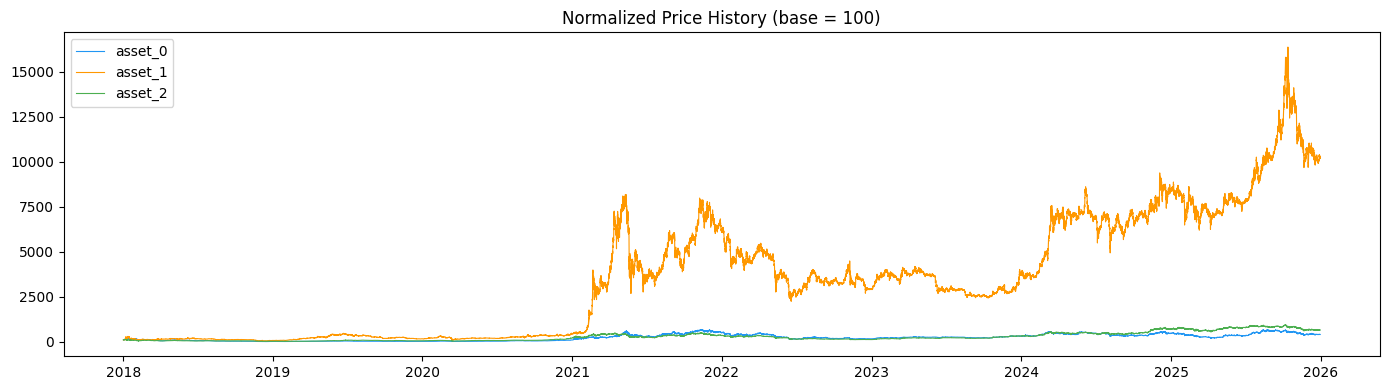


Total return over full period:
  asset_0: 308%
  asset_1: 10185%
  asset_2: 552%


In [4]:
closes = data[[f'{a}_close' for a in ASSETS]].rename(columns={f'{a}_close': a for a in ASSETS})
normalized = closes / closes.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 4))
for asset, color in zip(ASSETS, COLORS):
    ax.plot(normalized.index, normalized[asset], label=asset, color=color, linewidth=0.8)
ax.set_title('Normalized Price History (base = 100)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print('\nTotal return over full period:')
for asset in ASSETS:
    ret = (closes[asset].iloc[-1] / closes[asset].iloc[0] - 1) * 100
    print(f'  {asset}: {ret:.0f}%')

## 2. Return Distributions

Log-returns are what your agent ultimately works with. Notice the fat tails — large moves happen much more often than a normal distribution would predict.

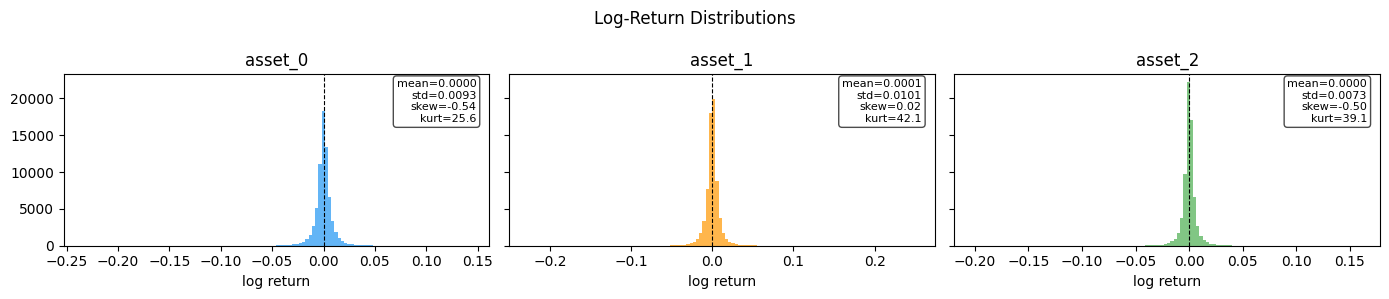

In [5]:
log_rets = np.log(closes / closes.shift(1)).dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=True)
for ax, asset, color in zip(axes, ASSETS, COLORS):
    r = log_rets[asset]
    ax.hist(r, bins=120, color=color, alpha=0.7, edgecolor='none')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(asset)
    ax.set_xlabel('log return')
    stats = f"mean={r.mean():.4f}\nstd={r.std():.4f}\nskew={r.skew():.2f}\nkurt={r.kurtosis():.1f}"
    ax.text(0.97, 0.97, stats, transform=ax.transAxes, va='top', ha='right', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
plt.suptitle('Log-Return Distributions')
plt.tight_layout()
plt.show()

## 3. Rolling Volatility

Volatility is not constant — it clusters. Calm periods and turbulent periods alternate. This is a key challenge for your agent: what works in a low-volatility regime may fail in a high-volatility one.

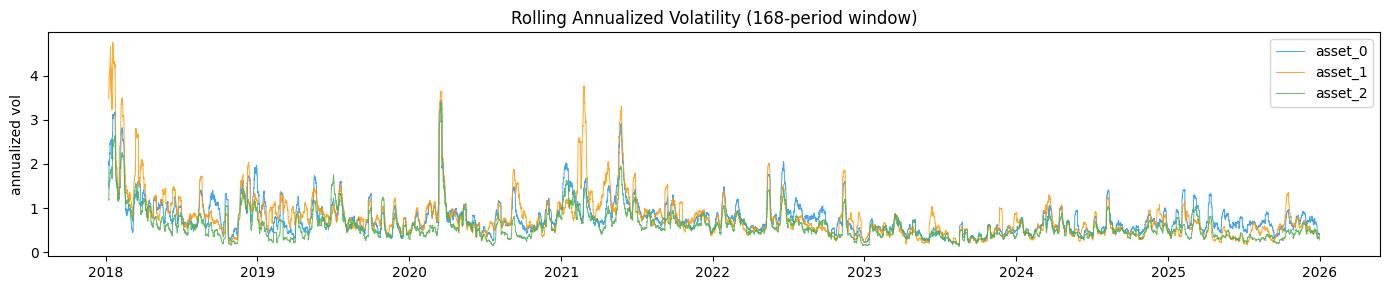

In [6]:
window = 24 * 7  # one week of hourly candles
vol = log_rets.rolling(window).std() * np.sqrt(24 * 365)  # annualized

fig, ax = plt.subplots(figsize=(14, 3))
for asset, color in zip(ASSETS, COLORS):
    ax.plot(vol.index, vol[asset], label=asset, color=color, linewidth=0.7, alpha=0.85)
ax.set_title(f'Rolling Annualized Volatility ({window}-period window)')
ax.set_ylabel('annualized vol')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 4. Correlation Between Assets

How correlated are the assets? High correlation means diversification offers less benefit. It also affects how your agent should think about portfolio construction.

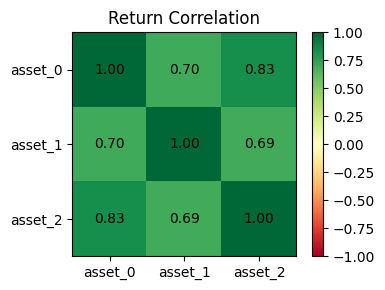

In [7]:
corr = log_rets.corr()

fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdYlGn')
ax.set_xticks(range(len(ASSETS))); ax.set_xticklabels(ASSETS)
ax.set_yticks(range(len(ASSETS))); ax.set_yticklabels(ASSETS)
for i in range(len(ASSETS)):
    for j in range(len(ASSETS)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax)
ax.set_title('Return Correlation')
plt.tight_layout()
plt.show()

## 5. Volume and Taker Buy Ratio

Volume spikes often precede or coincide with large price moves. The taker buy ratio (fraction of volume initiated by buyers) is a microstructure signal of short-term directional pressure.

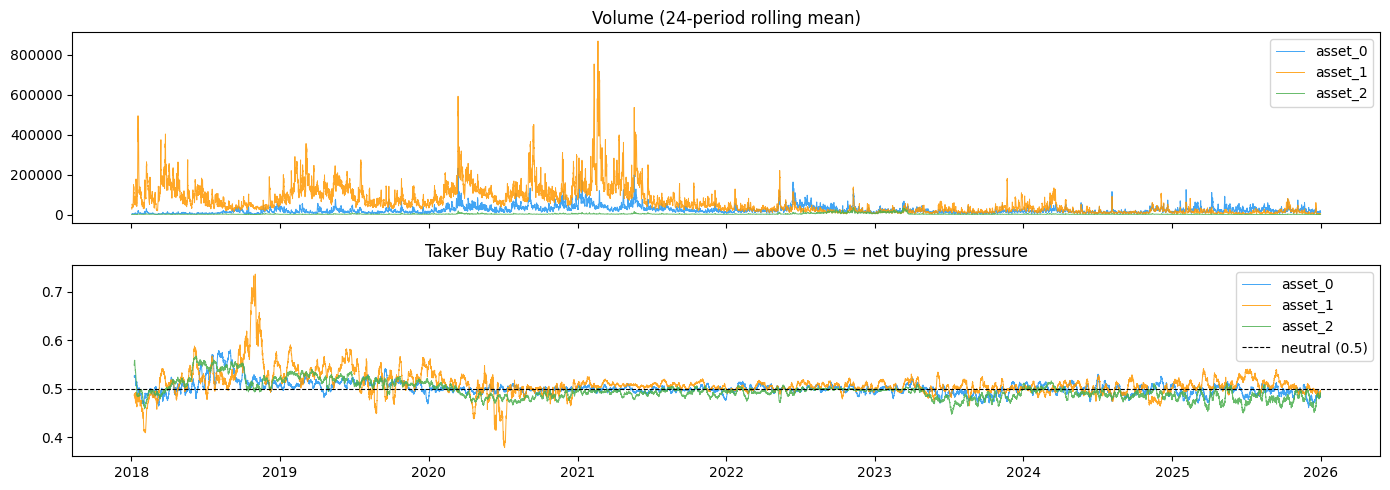

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

# Volume (rolling mean to smooth)
for asset, color in zip(ASSETS, COLORS):
    vol_series = data[f'{asset}_volume'].rolling(24).mean()
    axes[0].plot(vol_series.index, vol_series, label=asset, color=color, linewidth=0.7, alpha=0.85)
axes[0].set_title('Volume (24-period rolling mean)')
axes[0].legend()

# Taker buy ratio
for asset, color in zip(ASSETS, COLORS):
    tbr = data[f'{asset}_taker_buy_ratio'].rolling(24 * 7).mean()
    axes[1].plot(tbr.index, tbr, label=asset, color=color, linewidth=0.7, alpha=0.85)
axes[1].axhline(0.5, color='black', linewidth=0.8, linestyle='--', label='neutral (0.5)')
axes[1].set_title('Taker Buy Ratio (7-day rolling mean) — above 0.5 = net buying pressure')
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 6. Drawdown Profile

What does the worst-case look like for each asset? This should calibrate your expectations for how bad things can get, and inform your reward function design.

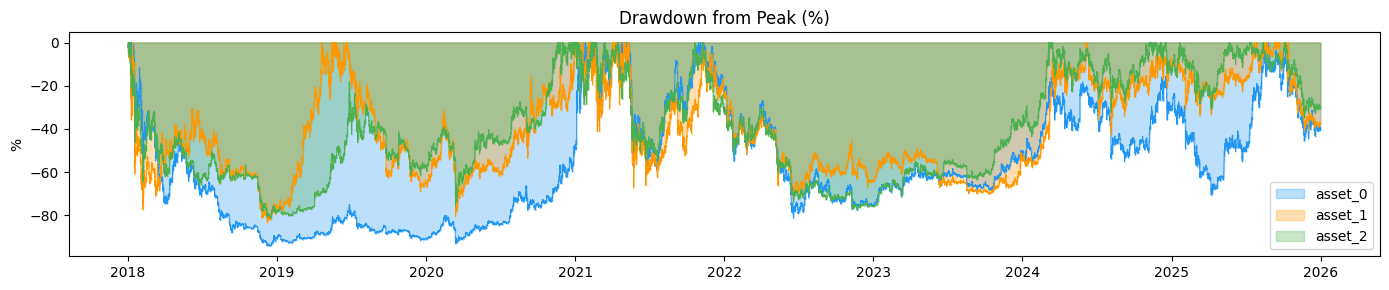

Max drawdown:
  asset_0: -94.3%
  asset_1: -83.4%
  asset_2: -81.4%


In [9]:
fig, ax = plt.subplots(figsize=(14, 3))
for asset, color in zip(ASSETS, COLORS):
    price = closes[asset]
    peak = price.cummax()
    dd = (price - peak) / peak * 100
    ax.fill_between(dd.index, dd, 0, alpha=0.3, color=color, label=asset)
    ax.plot(dd.index, dd, color=color, linewidth=0.6)
ax.set_title('Drawdown from Peak (%)')
ax.set_ylabel('%')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print('Max drawdown:')
for asset in ASSETS:
    price = closes[asset]
    peak = price.cummax()
    print(f'  {asset}: {((price - peak) / peak).min() * 100:.1f}%')

## 7. Pre-computed Features

A preview of what `build_features()` produces — these are available for your observation space out of the box.

In [10]:
features, _ = build_features(data, fit=True)
print(f'Feature matrix shape: {features.shape}')
print(f'\nFeatures available:')
for col in features.columns:
    print(f'  {col}')
print(f'\nSample (last 3 rows):')
features.tail(3).round(3)

Feature matrix shape: (69984, 18)

Features available:
  asset_0_log_ret
  asset_0_vol_21
  asset_0_mom_20
  asset_0_atr_14
  asset_0_vol_ratio
  asset_0_tbr
  asset_1_log_ret
  asset_1_vol_21
  asset_1_mom_20
  asset_1_atr_14
  asset_1_vol_ratio
  asset_1_tbr
  asset_2_log_ret
  asset_2_vol_21
  asset_2_mom_20
  asset_2_atr_14
  asset_2_vol_ratio
  asset_2_tbr

Sample (last 3 rows):


,asset_0_log_ret,asset_0_vol_21,asset_0_mom_20,asset_0_atr_14,asset_0_vol_ratio,asset_0_tbr,asset_1_log_ret,asset_1_vol_21,asset_1_mom_20,asset_1_atr_14,asset_1_vol_ratio,asset_1_tbr,asset_2_log_ret,asset_2_vol_21,asset_2_mom_20,asset_2_atr_14,asset_2_vol_ratio,asset_2_tbr
2025-12-30 22:59:59.999,0.031,-0.828,0.335,-0.682,-0.749,-1.128,0.035,-0.853,0.285,-0.858,-0.829,0.037,0.218,-0.698,0.460,-0.575,-0.786,-0.809
2025-12-30 23:59:59.999,0.148,-0.845,0.171,-0.711,-0.833,1.480,0.000,-0.877,0.213,-0.865,-0.531,-0.187,0.082,-0.715,0.382,-0.599,-0.800,2.184
2025-12-31 00:59:59.999,-0.266,-0.921,0.158,-0.721,-0.887,0.726,-0.264,-0.873,0.156,-0.852,-0.473,-1.569,-0.360,-0.707,0.329,-0.601,-0.849,0.338


## Key Takeaways

Before moving to `agent.py`, make sure you can answer:

1. **Volatility is regime-dependent.** Your agent will train on some regimes and be evaluated on others. How should your state capture this?
2. **Assets are correlated but not identical.** Diversification has value, but not as much as with truly uncorrelated assets.
3. **Drawdowns are severe.** A naive hold strategy can lose 80%+. Your reward function needs to account for this.
4. **Volume and taker buy ratio carry information.** Whether to include them in your state is a design decision — justify it.
5. **The data is noisy.** Do not expect your agent to find a clean signal. Focus on robustness over peak performance.

Calculando topología 18D para 2916 ventanas... (Esto tomará 1-2 minutos)
¡Cálculo terminado! Visualizando y generando reporte...



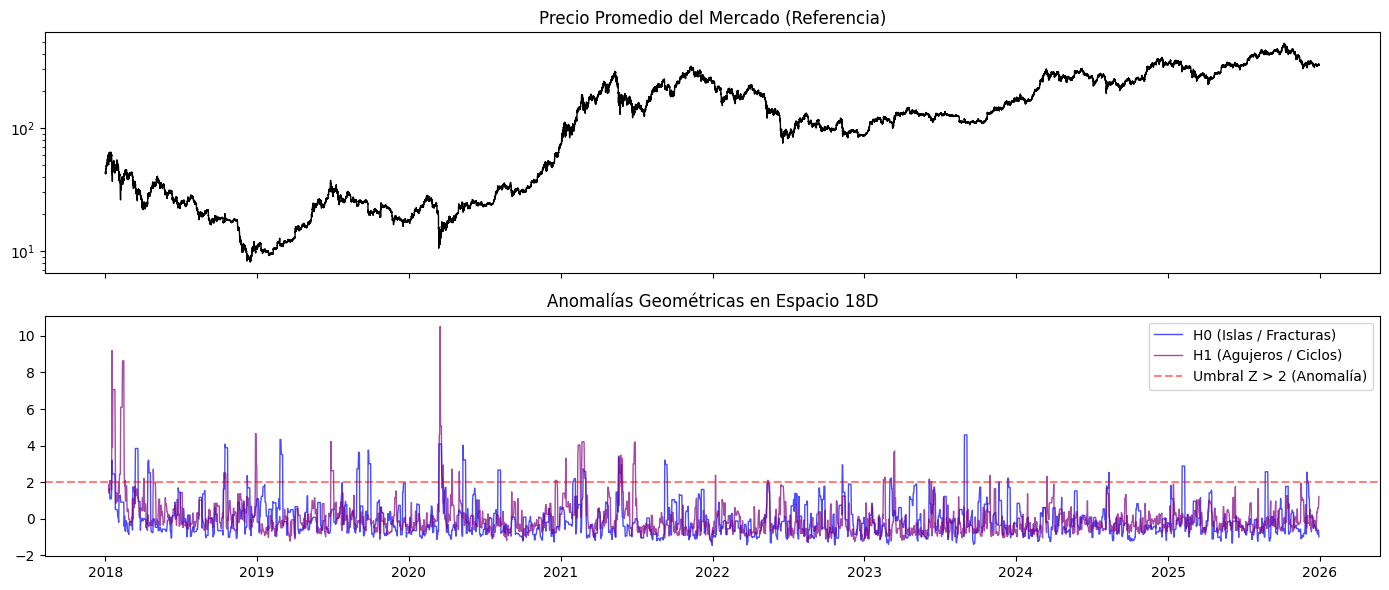


COPIA ESTE BLOQUE Y PÉGALO EN EL CHAT PARA ANALIZAR
Total Semanas Analizadas: 2909
Fracturas de Mercado (H0 Z>2): 141 detectadas
Ciclos Anómalos    (H1 Z>2): 107 detectadas

--- IMPACTO DE H0 (Fracturas) EN TURBULENCIA FUTURA ---
Asset 0 | Histórica: 8.70% | Tras H0: 6.87%
Asset 1 | Histórica: 8.33% | Tras H0: 12.50%
Asset 2 | Histórica: 6.50% | Tras H0: 5.96%

--- IMPACTO DE H1 (Ciclos) EN TURBULENCIA FUTURA ---
Asset 0 | Histórica: 8.70% | Tras H1: 9.95%
Asset 1 | Histórica: 8.33% | Tras H1: 15.53%
Asset 2 | Histórica: 6.50% | Tras H1: 9.60%


In [25]:
# =============================================================================
# EXPERIMENTO TDA FINAL: Topología en el Espacio de 18 Dimensiones
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from ripser import ripser
from scipy.stats import zscore

# 1. Verificar que 'features' existe en tu entorno
if 'features' not in locals():
    raise ValueError("¡Error! Debes correr primero la celda del profesor que define la variable 'features'.")

# 2. Parámetros del Experimento
WINDOW_SIZE = 168  # 1 semana de datos
STRIDE = 24        # Saltos de 24 horas para acelerar el cálculo

vals = features.values
h0_amplitudes = []
h1_amplitudes = []
indices = []

print(f"Calculando topología 18D para {len(vals) // STRIDE} ventanas... (Esto tomará 1-2 minutos)")

# 3. Bucle Principal TDA
for i in range(0, len(vals) - WINDOW_SIZE, STRIDE):
    # La nube de puntos ya es de 18 dimensiones (no necesitamos Takens Embedding)
    point_cloud = vals[i : i + WINDOW_SIZE]
    
    # Ripser
    dgms = ripser(point_cloud, maxdim=1)['dgms']
    
    # --- Procesamiento de H0 (Componentes Conexas / Islas) ---
    h0 = dgms[0]
    persistences_h0 = h0[:, 1] - h0[:, 0]
    # Filtramos los infinitos (la "isla principal" que nunca muere)
    persistences_h0 = persistences_h0[np.isfinite(persistences_h0)]
    # Buscamos la SEGUNDA isla más grande (la anomalía)
    max_h0 = np.max(persistences_h0) if len(persistences_h0) > 0 else 0.0
    
    # --- Procesamiento de H1 (Agujeros / Ciclos) ---
    h1 = dgms[1]
    persistences_h1 = h1[:, 1] - h1[:, 0]
    persistences_h1 = persistences_h1[np.isfinite(persistences_h1)]
    max_h1 = np.max(persistences_h1) if len(persistences_h1) > 0 else 0.0
    
    h0_amplitudes.append(max_h0)
    h1_amplitudes.append(max_h1)
    indices.append(i + WINDOW_SIZE - 1)

# 4. Alinear resultados con fechas
tda_dates = features.index[indices]
df_tda = pd.DataFrame({
    'H0_Max': h0_amplitudes,
    'H1_Max': h1_amplitudes
}, index=tda_dates)

# Calculamos Z-Scores para aislar anomalías estadísticas
df_tda['Z_H0'] = zscore(df_tda['H0_Max'])
df_tda['Z_H1'] = zscore(df_tda['H1_Max'])

print("¡Cálculo terminado! Visualizando y generando reporte...\n")

# 5. VISUALIZACIÓN
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Panel 1: Precio promedio del mercado (para referencia)
mercado_ref = data[['asset_0_close', 'asset_1_close', 'asset_2_close']].mean(axis=1)
axes[0].plot(mercado_ref.index, mercado_ref, color='black', linewidth=1)
axes[0].set_title('Precio Promedio del Mercado (Referencia)')
axes[0].set_yscale('log')

# Panel 2: Señales TDA (Z-Scores)
axes[1].plot(df_tda.index, df_tda['Z_H0'], color='blue', linewidth=1, alpha=0.7, label='H0 (Islas / Fracturas)')
axes[1].plot(df_tda.index, df_tda['Z_H1'], color='purple', linewidth=1, alpha=0.7, label='H1 (Agujeros / Ciclos)')
axes[1].axhline(2.0, color='red', linestyle='--', alpha=0.5, label='Umbral Z > 2 (Anomalía)')
axes[1].set_title('Anomalías Geométricas en Espacio 18D')
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

# =============================================================================
# 6. REPORTE ANALÍTICO (PARA COPIAR Y PEGAR)
# =============================================================================
print("\n" + "="*70)
print("COPIA ESTE BLOQUE Y PÉGALO EN EL CHAT PARA ANALIZAR")
print("="*70)

# Unimos con los precios de los 3 activos para ver qué pasa después
df_eval = df_tda.copy()
for i in range(3):
    df_eval[f'P_{i}'] = data[f'asset_{i}_close'].loc[df_eval.index]
    # Turbulencia = Retorno absoluto en los siguientes 7 días (168 horas)
    df_eval[f'Turb_{i}_7d'] = (data[f'asset_{i}_close'].shift(-168).loc[df_eval.index] / df_eval[f'P_{i}'] - 1).abs() * 100

turb_media_0 = df_eval['Turb_0_7d'].mean()
turb_media_1 = df_eval['Turb_1_7d'].mean()
turb_media_2 = df_eval['Turb_2_7d'].mean()

# Filtramos las anomalías
anomalias_h0 = df_eval[df_eval['Z_H0'] > 2.0]
anomalias_h1 = df_eval[df_eval['Z_H1'] > 2.0]

print(f"Total Semanas Analizadas: {len(df_eval)}")
print(f"Fracturas de Mercado (H0 Z>2): {len(anomalias_h0)} detectadas")
print(f"Ciclos Anómalos    (H1 Z>2): {len(anomalias_h1)} detectadas\n")

print("--- IMPACTO DE H0 (Fracturas) EN TURBULENCIA FUTURA ---")
print(f"Asset 0 | Histórica: {turb_media_0:.2f}% | Tras H0: {anomalias_h0['Turb_0_7d'].mean():.2f}%")
print(f"Asset 1 | Histórica: {turb_media_1:.2f}% | Tras H0: {anomalias_h0['Turb_1_7d'].mean():.2f}%")
print(f"Asset 2 | Histórica: {turb_media_2:.2f}% | Tras H0: {anomalias_h0['Turb_2_7d'].mean():.2f}%\n")

print("--- IMPACTO DE H1 (Ciclos) EN TURBULENCIA FUTURA ---")
print(f"Asset 0 | Histórica: {turb_media_0:.2f}% | Tras H1: {anomalias_h1['Turb_0_7d'].mean():.2f}%")
print(f"Asset 1 | Histórica: {turb_media_1:.2f}% | Tras H1: {anomalias_h1['Turb_1_7d'].mean():.2f}%")
print(f"Asset 2 | Histórica: {turb_media_2:.2f}% | Tras H1: {anomalias_h1['Turb_2_7d'].mean():.2f}%")
print("="*70)

In [3]:
import torch
import torch.nn as nn
import math

class MiniTradingRoberta(nn.Module):
    def __init__(self, input_dim=15, d_model=64, n_heads=4, n_layers=4, max_seq_len=170):
        super().__init__()
        self.d_model = d_model
        
        # 1. Proyección lineal de los datos crudos al espacio de embedding (64D)
        self.feature_projection = nn.Linear(input_dim, d_model)
        
        # 2. Los 4 Tokens Especiales (Vectores continuos aprendibles)
        # Se inicializan aleatoriamente y la red los ajusta durante el entrenamiento
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.sep_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.mask_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.pad_token = nn.Parameter(torch.zeros(1, 1, d_model)) # El PAD suele empezar en cero
        
        # 3. Embedding Posicional (Para que sepa el orden del tiempo)
        self.pos_embedding = nn.Parameter(torch.randn(1, max_seq_len, d_model))
        
        # 4. El corazón del Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_heads, 
            dim_feedforward=128, 
            dropout=0.1, 
            activation="gelu",
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # --- CABEZA FASE 1: MLM (Pre-entrenamiento) ---
        # Proyecta de 64D de vuelta a 15D para intentar adivinar los valores enmascarados
        self.mlm_head = nn.Linear(d_model, input_dim)

    def forward(self, x, attention_mask=None, is_mlm=False):
        """
        x: Tensor de forma (Batch, Secuencia_Real, Input_Dim)
        attention_mask: Tensor booleano indicando qué posiciones ignorar (PADs)
        """
        B, seq_len, _ = x.shape
        
        # Proyectar datos de mercado a 64D
        x_emb = self.feature_projection(x)
        
        # (Aquí iría la lógica externa para reemplazar horas aleatorias con self.mask_token si is_mlm=True)
        
        # Añadir [CLS] al inicio y [SEP] al final de cada secuencia en el batch
        cls_tokens = self.cls_token.expand(B, -1, -1)
        sep_tokens = self.sep_token.expand(B, -1, -1)
        
        # Concatenar: [CLS] + [Datos de Mercado] + [SEP]
        sequence = torch.cat((cls_tokens, x_emb, sep_tokens), dim=1)
        
        # Sumar el embedding posicional (solo hasta la longitud actual)
        sequence = sequence + self.pos_embedding[:, :sequence.size(1), :]
        
        # Pasar por el Transformer
        # El attention_mask evita que la red mire los tokens [PAD] si los hay
        transformer_out = self.transformer(sequence, src_key_padding_mask=attention_mask)
        
        # El "Estado Latente" es la salida correspondiente al token [CLS] (índice 0)
        latent_state = transformer_out[:, 0, :] 
        
        if is_mlm:
            # Si estamos pre-entrenando, intentamos reconstruir el mercado
            reconstruction = self.mlm_head(transformer_out[:, 1:-1, :]) # Ignoramos CLS y SEP
            return reconstruction
            
        # Si estamos en TDA o RL, devolvemos el estado latente puro
        return latent_state


class TradingRLAgent(nn.Module):
    def __init__(self, encoder: MiniTradingRoberta, n_actions=5):
        super().__init__()
        self.encoder = encoder
        
        # Confinamos los pesos del encoder si queremos que mantenga lo aprendido en MLM
        # for param in self.encoder.parameters():
        #     param.requires_grad = False
        
        # --- CABEZA FASE 2: Fusión para RL ---
        # Aquí cruzamos el Estado Latente (64D) con las proporciones del agente (4D)
        
        # Opción elegante: Proyectamos los pesos a un vector pequeño y concatenamos
        self.portfolio_proj = nn.Linear(4, 16) 
        
        # Capa de decisión final (64 + 16 = 80D)
        self.actor = nn.Sequential(
            nn.Linear(64 + 16, 32),
            nn.ReLU(),
            nn.Linear(32, n_actions),
            nn.Softmax(dim=-1) # Probabilidades para cada acción
        )
        
        # Capa Crítico (opcional pero necesaria en algoritmos como PPO)
        self.critic = nn.Sequential(
            nn.Linear(64 + 16, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Estima el valor esperado del estado
        )

    def forward(self, market_window, agent_weights, attention_mask=None):
        # 1. Obtener el estado geométrico puro (El espacio sobre el que harías TDA)
        latent_state = self.encoder(market_window, attention_mask=attention_mask, is_mlm=False)
        
        # 2. Procesar los pesos del portafolio actual
        # agent_weights forma: [Peso_A0, Peso_A1, Peso_A2, Peso_Cash]
        port_emb = torch.relu(self.portfolio_proj(agent_weights))
        
        # 3. Fusión de ambos mundos (El Mercado + Mi Billetera)
        fused_state = torch.cat((latent_state, port_emb), dim=-1)
        
        # 4. Decisión
        action_probs = self.actor(fused_state)
        state_value = self.critic(fused_state)
        
        return action_probs, state_value, latent_state

In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

def build_raw_stationary(data: pd.DataFrame, scaler=None, fit=False):
    """
    Transformación MÍNIMA. Sin ventanas rodantes, solo haciendo 
    los datos seguros para una Red Neuronal.
    """
    frames = []
    assets = ['asset_0', 'asset_1', 'asset_2']
    
    for asset in assets:
        close = data[f"{asset}_close"]
        high = data[f"{asset}_high"]
        low = data[f"{asset}_low"]
        vol = data[f"{asset}_volume"]
        tbr = data[f"{asset}_taker_buy_ratio"]
        
        # 1. Retornos en lugar de precios absolutos
        log_ret = np.log(close / close.shift(1))
        
        # 2. Amplitud de la vela (High vs Low) en porcentaje
        amplitude = (high - low) / close.shift(1)
        
        f = pd.DataFrame({
            f"{asset}_log_ret": log_ret,
            f"{asset}_amplitude": amplitude,
            f"{asset}_vol": vol, # El volumen absoluto también se debe escalar
            f"{asset}_tbr": tbr, # Ya está entre 0 y 1, pero lo escalaremos igual
        })
        frames.append(f)
        
    X = pd.concat(frames, axis=1).dropna()
    
    if scaler is None:
        scaler = StandardScaler()
    if fit:
        scaler.fit(X.values)
        
    # Devolvemos los datos normalizados (media 0, varianza 1)
    return pd.DataFrame(scaler.transform(X.values), index=X.index, columns=X.columns), scaler

In [5]:
import torch
from torch.utils.data import Dataset
import numpy as np

class MarketMLMDataset(Dataset):
    def __init__(self, features_df, max_len=168, min_len=10, mask_prob=0.15):
        """
        features_df: Tu DataFrame con las 15 o 18 características escaladas.
        max_len: 168 (1 semana)
        min_len: El tamaño mínimo de historia que el agente podría tener al arrancar.
        mask_prob: Probabilidad de ocultar una hora para que la red la adivine (15%).
        """
        self.data = torch.FloatTensor(features_df.values)
        self.max_len = max_len
        self.min_len = min_len
        self.mask_prob = mask_prob
        
        # Total de filas disponibles para evitar salirnos del límite
        self.total_rows = len(self.data)

    def __len__(self):
        # Un número arbitrario de "ejemplos" por época. 
        # Como tomamos ventanas aleatorias, podemos definir la longitud que queramos.
        return self.total_rows - self.max_len

    def __getitem__(self, idx):
        # 1. Elegir un tamaño de historia aleatorio entre min_len y max_len
        # Esto enseña a la red a usar el token [PAD]
        seq_len = np.random.randint(self.min_len, self.max_len + 1)
        
        # 2. Elegir un punto de inicio aleatorio en la historia
        start_idx = np.random.randint(0, self.total_rows - seq_len)
        end_idx = start_idx + seq_len
        
        # 3. Extraer la ventana real de datos
        window = self.data[start_idx:end_idx].clone()
        
        # 4. Crear la máscara de MLM (qué horas vamos a obligar a la red a adivinar)
        # Generamos números aleatorios; si es < 0.15, marcamos como True (Ocultar)
        mlm_mask = torch.rand(seq_len) < self.mask_prob
        
        # 5. Rellenar con ceros hasta max_len (Padding)
        pad_len = self.max_len - seq_len
        if pad_len > 0:
            padding = torch.zeros((pad_len, window.shape[1]))
            window_padded = torch.cat((window, padding), dim=0)
            
            # La máscara MLM también necesita padding (False para las zonas vacías)
            mlm_mask_padded = torch.cat((mlm_mask, torch.zeros(pad_len, dtype=torch.bool)), dim=0)
        else:
            window_padded = window
            mlm_mask_padded = mlm_mask
            
        # 6. Crear la Attention Mask (True significa "Ignorar este token")
        # El bloque Transformer de PyTorch requiere True en las posiciones de PAD
        padding_mask = torch.zeros(self.max_len, dtype=torch.bool)
        if pad_len > 0:
            padding_mask[-pad_len:] = True # Las últimas 'pad_len' posiciones se ignoran
            
        # Devolvemos:
        # window_padded: Datos reales + Ceros
        # padding_mask: Dónde están los ceros (para ignorarlos en la atención)
        # mlm_mask_padded: Qué horas reales debe adivinar la red
        return window_padded, padding_mask, mlm_mask_padded

In [77]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm # Para la barra de progreso

# =============================================================================
# 1. CONSTRUCCIÓN DE FEATURES (Mínima Estacionariedad)
# =============================================================================
def build_raw_stationary(data: pd.DataFrame, scaler=None, fit=False):
    """
    Transformación MÍNIMA. Sin ventanas rodantes.
    Solo calcula retornos y estandariza para que la red neuronal pueda digerirlos.
    """
    frames = []
    assets = ['asset_0', 'asset_1', 'asset_2']
    
    for asset in assets:
        close = data[f"{asset}_close"]
        high = data[f"{asset}_high"]
        low = data[f"{asset}_low"]
        vol = data[f"{asset}_volume"]
        tbr = data[f"{asset}_taker_buy_ratio"]
        
        # Retornos logarítmicos de 1 hora
        log_ret = np.log(close / close.shift(1))
        # Amplitud de la vela
        amplitude = (high - low) / close.shift(1)
        
        f = pd.DataFrame({
            f"{asset}_log_ret": log_ret,
            f"{asset}_amplitude": amplitude,
            f"{asset}_vol": vol, 
            f"{asset}_tbr": tbr, 
        })
        frames.append(f)
        
    X = pd.concat(frames, axis=1).dropna()
    
    if scaler is None:
        scaler = StandardScaler()
    if fit:
        scaler.fit(X.values)
        
    # Devolvemos un DataFrame con las 12 características limpias (4 por activo)
    return pd.DataFrame(scaler.transform(X.values), index=X.index, columns=X.columns), scaler

# =============================================================================
# 2. DATASET (Generador de Ventanas Dinámicas)
# =============================================================================
class MarketMLMDataset(Dataset):
    def __init__(self, features_df, max_len=168, min_len=10, mask_prob=0.15):
        self.data = torch.FloatTensor(features_df.values)
        self.max_len = max_len
        self.min_len = min_len
        self.mask_prob = mask_prob
        self.total_rows = len(self.data)

    def __len__(self):
        return self.total_rows - self.max_len

    def __getitem__(self, idx):
        seq_len = np.random.randint(self.min_len, self.max_len + 1)
        start_idx = np.random.randint(0, self.total_rows - seq_len)
        end_idx = start_idx + seq_len
        
        window = self.data[start_idx:end_idx].clone()
        
        # --- NUEVA LÓGICA DE ENMASCARAMIENTO (Tail + Body) ---
        mlm_mask = torch.zeros(seq_len, dtype=torch.bool)
        
        # 1. Enmascarar la "Cola" (El último 10% de la secuencia real)
        # Usamos max(1, ...) para garantizar que siempre oculte al menos la última hora
        tail_len = max(1, int(seq_len * 0.10)) 
        mlm_mask[-tail_len:] = True
        
        # 2. Enmascarar el "Cuerpo" (Ruido aleatorio del 5% en el pasado)
        body_len = seq_len - tail_len
        if body_len > 0:
            body_mask = torch.rand(body_len) < 0.05
            mlm_mask[:body_len] = body_mask
        # -----------------------------------------------------
        
        pad_len = self.max_len - seq_len
        if pad_len > 0:
            padding = torch.zeros((pad_len, window.shape[1]))
            window_padded = torch.cat((window, padding), dim=0)
            mlm_mask_padded = torch.cat((mlm_mask, torch.zeros(pad_len, dtype=torch.bool)), dim=0)
        else:
            window_padded = window
            mlm_mask_padded = mlm_mask
            
        padding_mask = torch.zeros(self.max_len, dtype=torch.bool)
        if pad_len > 0:
            padding_mask[-pad_len:] = True
            
        return window_padded, padding_mask, mlm_mask_padded

# =============================================================================
# 3. ARQUITECTURA DEL MODELO (El Mini-Transformer)
# =============================================================================
class MiniTradingRoberta(nn.Module):
    def __init__(self, input_dim=12, d_model=64, n_heads=4, n_layers=2, max_seq_len=170):
        super().__init__()
        self.d_model = d_model
        
        self.feature_projection = nn.Linear(input_dim, d_model)
        
        # Vectores especiales continuos
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.sep_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.mask_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.pad_token = nn.Parameter(torch.zeros(1, 1, d_model))
        
        self.pos_embedding = nn.Parameter(torch.randn(1, max_seq_len, d_model))
        
        # Transformer Layer con GELU
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=128, 
            dropout=0.1, activation="gelu", batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # Cabeza para reconstruir el dato original en la fase MLM
        self.mlm_head = nn.Linear(d_model, input_dim)

    def forward(self, x, padding_mask=None, mlm_mask=None, is_mlm=False):
        B, seq_len, _ = x.shape
        
        # 1. Proyectamos datos crudos a 64D
        x_emb = self.feature_projection(x)
        
        # 2. INYECCIÓN DE TOKENS (El truco matemático)
        # Si la posición está marcada como PAD, reemplazamos su vector por el pad_token
        if padding_mask is not None:
            x_emb = torch.where(padding_mask.unsqueeze(-1), self.pad_token, x_emb)
        
        # Si la posición está marcada como MASK (y estamos entrenando), la tapamos
        if is_mlm and mlm_mask is not None:
            x_emb = torch.where(mlm_mask.unsqueeze(-1), self.mask_token, x_emb)
            
        # 3. Añadir [CLS] al inicio y [SEP] al final
        cls_tokens = self.cls_token.expand(B, -1, -1)
        sep_tokens = self.sep_token.expand(B, -1, -1)
        sequence = torch.cat((cls_tokens, x_emb, sep_tokens), dim=1)
        
        # 4. Sumar el tiempo (Positional Embedding)
        sequence = sequence + self.pos_embedding[:, :sequence.size(1), :]
        
        # 5. Ajustar la máscara para el Transformer (para que no ignore el CLS ni el SEP)
        # padding_mask es de tamaño 168. La secuencia ahora es 170.
        if padding_mask is not None:
            cls_pad = torch.zeros((B, 1), dtype=torch.bool, device=x.device)
            sep_pad = torch.zeros((B, 1), dtype=torch.bool, device=x.device)
            transformer_pad_mask = torch.cat((cls_pad, padding_mask, sep_pad), dim=1)
        else:
            transformer_pad_mask = None
            
        # 6. Procesar la magia de la Auto-Atención
        transformer_out = self.transformer(sequence, src_key_padding_mask=transformer_pad_mask)
        
        # 7. Salidas
        if is_mlm:
            # Reconstruimos las 168 horas centrales (ignoramos CLS [0] y SEP [-1])
            reconstruction = self.mlm_head(transformer_out[:, 1:-1, :]) 
            return reconstruction
            
        # Si no es MLM, devolvemos el estado latente del CLS
        return transformer_out[:, 0, :]

In [37]:
# =============================================================================
# 4. SCRIPT DE EJECUCIÓN: ENTRENAMIENTO MLM CON VALIDACIÓN Y SPLIT
# =============================================================================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# ---------------------------------------------------------
# A. DIVISIÓN CRONOLÓGICA DE LOS DATOS (SPLIT)
# ---------------------------------------------------------
# Total: ~70,000 filas. 
# Usaremos el 70% para Entrenar MLM, 15% para Validar MLM, 15% reservado para RL.
n_total = len(data)
train_end = int(n_total * 0.70)
val_end = int(n_total * 0.85)

data_train = data.iloc[:train_end].copy()
data_val = data.iloc[train_end:val_end].copy()
data_rl_test = data.iloc[val_end:].copy() # Intacto para el futuro

print(f"Split de Datos | Train: {len(data_train)} | Val: {len(data_val)} | RL Test: {len(data_rl_test)}")

Usando dispositivo: cuda
Split de Datos | Train: 49003 | Val: 10501 | RL Test: 10501


In [38]:
# ---------------------------------------------------------
# B. CONSTRUCCIÓN DE FEATURES (Sin Fuga de Datos)
# ---------------------------------------------------------
# 1. Ajustamos el Scaler SOLO con el conjunto de entrenamiento
features_train, scaler = build_raw_stationary(data_train, fit=True)

# 2. Aplicamos ese mismo Scaler al conjunto de validación a ciegas
features_val, _ = build_raw_stationary(data_val, scaler=scaler, fit=False)

INPUT_DIM = features_train.shape[1]

# ---------------------------------------------------------
# C. DATASETS Y DATALOADERS
# ---------------------------------------------------------
# Dataset de entrenamiento genera ventanas aleatorias infinitas
dataset_train = MarketMLMDataset(features_train, max_len=168, min_len=10, mask_prob=0.15)
loader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)

# Dataset de validación (podemos usar menos datos para que evalúe más rápido)
dataset_val = MarketMLMDataset(features_val, max_len=168, min_len=10, mask_prob=0.15)
# Reducimos artificialmente el tamaño del val_loader para no esperar tanto en cada época
loader_val = DataLoader(dataset_val, batch_size=32, shuffle=False)

# ---------------------------------------------------------
# D. INICIALIZACIÓN DEL MODELO Y LÍNEA BASE
# ---------------------------------------------------------
modelo = MiniTradingRoberta(input_dim=INPUT_DIM, d_model=64, n_heads=4, n_layers=3)
modelo = modelo.to(device)

optimizer = torch.optim.AdamW(modelo.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# Línea Base (Baseline): ¿Qué pasa si el modelo adivina "0" (la media histórica)?
# Como estandarizamos, la varianza es ~1.0, por lo que adivinar 0 da un MSE de ~1.0.
print("\nLínea Base Teórica (Adivinar 0): MSE ~ 1.000")
print("Cualquier valor menor a 1.000 significa que el modelo está descubriendo información real.\n")

# ---------------------------------------------------------
# E. BUCLE DE ENTRENAMIENTO Y VALIDACIÓN
# ---------------------------------------------------------
EPOCHS = 100 # Ponemos un número alto, el sistema lo detendrá antes
paciencia = 10 # Cuántas épocas esperaremos si la validación no mejora
contador_paciencia = 0
mejor_val_loss = float('inf')

for epoch in range(EPOCHS):
    # --- FASE DE ENTRENAMIENTO ---
    modelo.train()
    train_loss = 0
    pbar_train = tqdm(loader_train, desc=f"Train Epoch {epoch+1}/{EPOCHS}")
    
    for ventanas, pad_masks, mlm_masks in pbar_train:
        ventanas, pad_masks, mlm_masks = ventanas.to(device), pad_masks.to(device), mlm_masks.to(device)
        
        optimizer.zero_grad()
        reconstruccion = modelo(ventanas, padding_mask=pad_masks, mlm_mask=mlm_masks, is_mlm=True)
        
        predicciones = reconstruccion[mlm_masks]
        valores_reales = ventanas[mlm_masks]
        
        if predicciones.numel() == 0: continue
            
        loss = criterion(predicciones, valores_reales)
        loss.backward()
        
        # Clipping de gradientes (buena práctica para evitar que la red explote con picos de volatilidad)
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_loss += loss.item()
        pbar_train.set_postfix({'MSE': f"{loss.item():.4f}"})
        
    avg_train_loss = train_loss / len(loader_train)
    
    # --- FASE DE VALIDACIÓN ---
    modelo.eval()
    val_loss = 0
    batches_evaluados = 0
    
    # max_val_batches limita cuántos lotes evaluamos para no demorar horas
    max_val_batches = min(1000, len(loader_val)) 
    
    with torch.no_grad(): # Apagamos el cálculo de gradientes
        for i, (ventanas, pad_masks, mlm_masks) in enumerate(loader_val):
            if i >= max_val_batches: break
                
            ventanas, pad_masks, mlm_masks = ventanas.to(device), pad_masks.to(device), mlm_masks.to(device)
            reconstruccion = modelo(ventanas, padding_mask=pad_masks, mlm_mask=mlm_masks, is_mlm=True)
            
            predicciones = reconstruccion[mlm_masks]
            valores_reales = ventanas[mlm_masks]
            
            if predicciones.numel() == 0: continue
                
            loss = criterion(predicciones, valores_reales)
            val_loss += loss.item()
            batches_evaluados += 1
            
    avg_val_loss = val_loss / batches_evaluados if batches_evaluados > 0 else float('inf')
    
    print(f"-> [Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}\n")

    
    # --- LÓGICA DE EARLY STOPPING ---
    if avg_val_loss < mejor_val_loss:
        # ¡Nuevo récord! Guardamos el modelo en el disco duro
        mejor_val_loss = avg_val_loss
        contador_paciencia = 0
        torch.save(modelo.state_dict(), "mejor_modelo_mlm.pth")
        print("   ¡Nuevo mejor modelo guardado!")
    else:
        # El modelo empeoró o se estancó
        contador_paciencia += 1
        print(f"   Sin mejora. Paciencia: {contador_paciencia}/{paciencia}")
        
        if contador_paciencia >= paciencia:
            print("\n🚨 ¡Early Stopping activado! El modelo empezó a sobreajustar.")
            break # Rompe el bucle de las 100 épocas

print("Entrenamiento finalizado. El modelo no ha visto los datos de RL Test.")
# Al final del script, recargamos la mejor versión que se guardó
modelo.load_state_dict(torch.load("mejor_modelo_mlm.pth"))
print("Pesos óptimos restaurados. Listo para RL.")

Usando dispositivo: cuda
Split de Datos | Train: 49003 | Val: 10501 | RL Test: 10501

Línea Base Teórica (Adivinar 0): MSE ~ 1.000
Cualquier valor menor a 1.000 significa que el modelo está descubriendo información real.



Train Epoch 1/100: 100%|██████████| 1527/1527 [00:41<00:00, 36.99it/s, MSE=1.3824]


-> [Epoch 1] Train Loss: 0.8258 | Val Loss: 0.4352

   ¡Nuevo mejor modelo guardado!


Train Epoch 2/100: 100%|██████████| 1527/1527 [00:43<00:00, 34.85it/s, MSE=0.2050]


-> [Epoch 2] Train Loss: 0.7971 | Val Loss: 0.4361

   Sin mejora. Paciencia: 1/10


...

-> [Epoch 39] Train Loss: 0.7540 | Val Loss: 0.4218

   Sin mejora. Paciencia: 8/10


Train Epoch 40/100: 100%|██████████| 1527/1527 [00:44<00:00, 34.25it/s, MSE=0.3265]


-> [Epoch 40] Train Loss: 0.7724 | Val Loss: 0.4198

   Sin mejora. Paciencia: 9/10


Train Epoch 41/100: 100%|██████████| 1527/1527 [00:44<00:00, 34.05it/s, MSE=0.3096]


-> [Epoch 41] Train Loss: 0.7572 | Val Loss: 0.4271

   Sin mejora. Paciencia: 10/10

🚨 ¡Early Stopping activado! El modelo empezó a sobreajustar.
Entrenamiento finalizado. El modelo no ha visto los datos de RL Test.
Pesos óptimos restaurados. Listo para RL.


In [39]:
features_train, scaler = build_raw_stationary(data_train, fit=True)

# 2. Aplicamos ese mismo Scaler al conjunto de validación a ciegas
features_val, _ = build_raw_stationary(data_val, scaler=scaler, fit=False)

INPUT_DIM = features_train.shape[1]

# ---------------------------------------------------------
# C. DATASETS Y DATALOADERS
# ---------------------------------------------------------
# Dataset de entrenamiento genera ventanas aleatorias infinitas
dataset_train = MarketMLMDataset(features_train, max_len=168, min_len=10, mask_prob=0.15)
loader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)

# Dataset de validación (podemos usar menos datos para que evalúe más rápido)
dataset_val = MarketMLMDataset(features_val, max_len=168, min_len=10, mask_prob=0.15)
# Reducimos artificialmente el tamaño del val_loader para no esperar tanto en cada época
loader_val = DataLoader(dataset_val, batch_size=32, shuffle=False)

C:\Users\ddfa9\AppData\Local\Temp\ipykernel_35396\815772204.py:55: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  self.data = torch.FloatTensor(features_df.values)


Extrayendo vectores latentes (64D) del Transformer...


  0%|          | 0/431 [00:00<?, ?it/s]

100%|██████████| 431/431 [00:01<00:00, 400.18it/s]



Calculando homología simplicial (H0 y H1) con ventana de 90...


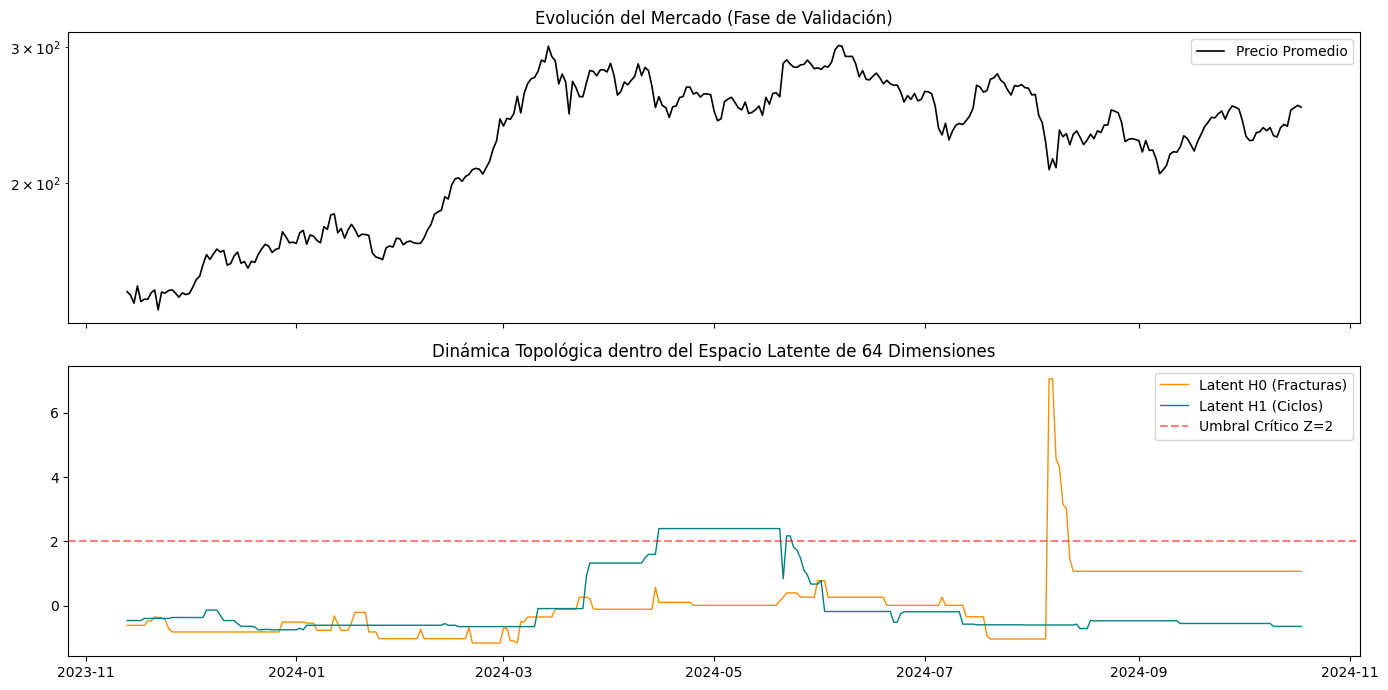


REPORTE ESTADÍSTICO DEL ESPACIO LATENTE
[METADATA_ESPACIO_LATENTE]
Total_Observaciones: 341
Ventana_Topologica: 90
Conteo_Anomalias_H0 (Fracturas): 6
Conteo_Anomalias_H1 (Ciclos): 38

[BASELINE_MERCADO]
Turbulencia_Promedio_7D: 6.24%
Turbulencia_Promedio_14D: 8.87%

[SEÑALES_H0_FRACTURAS]
Turbulencia_Post_H0_7D: 6.30% (Multiplicador: 1.01x)
Turbulencia_Post_H0_14D: 9.84% (Multiplicador: 1.11x)

[SEÑALES_H1_CICLOS]
Turbulencia_Post_H1_7D: 5.44% (Multiplicador: 0.87x)
Turbulencia_Post_H1_14D: 7.09% (Multiplicador: 0.80x)


In [54]:
# =============================================================================
# EXPERIMENTO: TDA SOBRE EL ESPACIO LATENTE (64 DIMENSIONES)
# =============================================================================
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from ripser import ripser
from scipy.stats import zscore
import warnings
from tqdm import tqdm

# Ignoramos warnings residuales si los datos llegan a ser muy planos en TDA
warnings.filterwarnings("ignore", category=UserWarning, module="ripser")

# 1. CONFIGURACIÓN Y EXTRACCIÓN DE VECTORES
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
modelo = MiniTradingRoberta(input_dim=INPUT_DIM, d_model=64, n_heads=4, n_layers=3)
modelo = modelo.to(device)
modelo.load_state_dict(torch.load("encoder_predictive.pth"))
modelo.eval() # Apagar Dropout es obligatorio para extraer representaciones puras

features_to_analyze = features_val # Usamos el set de validación
vals_crudos = features_to_analyze.values

MAX_LEN = 168
STRIDE = 24  
latent_vectors = []
timestamps = []

print("Extrayendo vectores latentes (64D) del Transformer...")
with torch.no_grad():
    for i in tqdm(range(0, len(vals_crudos) - MAX_LEN, STRIDE)):
        window_data = vals_crudos[i : i + MAX_LEN]
        window_tensor = torch.FloatTensor(window_data).unsqueeze(0).to(device)
        
        # is_mlm=False devuelve el estado latente puro del token [CLS]
        cls_state = modelo(window_tensor, padding_mask=None, mlm_mask=None, is_mlm=False)
        
        latent_vectors.append(cls_state.cpu().squeeze(0).numpy())
        timestamps.append(features_to_analyze.index[i + MAX_LEN - 1])

latent_cloud = np.array(latent_vectors)

# 2. CÁLCULO TOPOLÓGICO (RIPSER)
TDA_WINDOW = 90  # Obligatorio N > d (90 puntos > 64 dimensiones) para estabilidad matemática
latent_h0_amplitudes = []
latent_h1_amplitudes = []
tda_indices = []

print(f"\nCalculando homología simplicial (H0 y H1) con ventana de {TDA_WINDOW}...")
for i in range(0, len(latent_cloud) - TDA_WINDOW):
    point_cloud_64d = latent_cloud[i : i + TDA_WINDOW]
    
    dgms = ripser(point_cloud_64d, maxdim=1)['dgms']
    
    # Procesar H0 (Fracturas / Islas)
    h0 = dgms[0]
    persistences_h0 = h0[:, 1] - h0[:, 0]
    persistences_h0 = persistences_h0[np.isfinite(persistences_h0)]
    max_h0 = np.max(persistences_h0) if len(persistences_h0) > 0 else 0.0
    
    # Procesar H1 (Ciclos / Bucles)
    h1 = dgms[1]
    persistences_h1 = h1[:, 1] - h1[:, 0]
    max_h1 = np.max(persistences_h1) if len(persistences_h1) > 0 else 0.0
    
    latent_h0_amplitudes.append(max_h0)
    latent_h1_amplitudes.append(max_h1)
    tda_indices.append(i + TDA_WINDOW - 1)

# Empaquetar en DataFrame y calcular anomalías estadísticas
latent_tda_dates = [timestamps[idx] for idx in tda_indices]
df_latent_tda = pd.DataFrame({
    'Latent_H0': latent_h0_amplitudes,
    'Latent_H1': latent_h1_amplitudes
}, index=latent_tda_dates)

df_latent_tda['Z_Latent_H0'] = zscore(df_latent_tda['Latent_H0'])
df_latent_tda['Z_Latent_H1'] = zscore(df_latent_tda['Latent_H1'])

# 3. VISUALIZACIÓN
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Panel 1: Precio Promedio
mercado_ref = data.loc[df_latent_tda.index, ['asset_0_close', 'asset_1_close', 'asset_2_close']].mean(axis=1)
axes[0].plot(mercado_ref.index, mercado_ref, color='black', linewidth=1.2, label='Precio Promedio')
axes[0].set_title('Evolución del Mercado (Fase de Validación)')
axes[0].set_yscale('log')
axes[0].legend()

# Panel 2: Señales TDA
axes[1].plot(df_latent_tda.index, df_latent_tda['Z_Latent_H0'], color='darkorange', linewidth=1, label='Latent H0 (Fracturas)')
axes[1].plot(df_latent_tda.index, df_latent_tda['Z_Latent_H1'], color='teal', linewidth=1, label='Latent H1 (Ciclos)')
axes[1].axhline(2.0, color='red', linestyle='--', alpha=0.5, label='Umbral Crítico Z=2')
axes[1].set_title('Dinámica Topológica dentro del Espacio Latente de 64 Dimensiones')
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.show()

# =============================================================================
# 4. REPORTE ESTADÍSTICO
# =============================================================================
print("\n" + "="*80)
print("REPORTE ESTADÍSTICO DEL ESPACIO LATENTE")
print("="*80)

df_eval = df_latent_tda.copy()
for i in range(3):
    df_eval[f'P_{i}'] = data[f'asset_{i}_close'].loc[df_eval.index]
    df_eval[f'Ret_Abs_7d_A{i}'] = (data[f'asset_{i}_close'].shift(-168).loc[df_eval.index] / df_eval[f'P_{i}'] - 1).abs() * 100
    df_eval[f'Ret_Abs_14d_A{i}'] = (data[f'asset_{i}_close'].shift(-336).loc[df_eval.index] / df_eval[f'P_{i}'] - 1).abs() * 100

turb_base_7d = df_eval[[f'Ret_Abs_7d_A{i}' for i in range(3)]].mean().mean()
turb_base_14d = df_eval[[f'Ret_Abs_14d_A{i}' for i in range(3)]].mean().mean()

anomalias_h0 = df_eval[df_eval['Z_Latent_H0'] > 2.0]
anomalias_h1 = df_eval[df_eval['Z_Latent_H1'] > 2.0]

print(f"[METADATA_ESPACIO_LATENTE]")
print(f"Total_Observaciones: {len(df_eval)}")
print(f"Ventana_Topologica: {TDA_WINDOW}")
print(f"Conteo_Anomalias_H0 (Fracturas): {len(anomalias_h0)}")
print(f"Conteo_Anomalias_H1 (Ciclos): {len(anomalias_h1)}")

print(f"\n[BASELINE_MERCADO]")
print(f"Turbulencia_Promedio_7D: {turb_base_7d:.2f}%")
print(f"Turbulencia_Promedio_14D: {turb_base_14d:.2f}%")

print(f"\n[SEÑALES_H0_FRACTURAS]")
if not anomalias_h0.empty:
    turb_h0_7d = anomalias_h0[[f'Ret_Abs_7d_A{i}' for i in range(3)]].mean().mean()
    turb_h0_14d = anomalias_h0[[f'Ret_Abs_14d_A{i}' for i in range(3)]].mean().mean()
    print(f"Turbulencia_Post_H0_7D: {turb_h0_7d:.2f}% (Multiplicador: {turb_h0_7d/turb_base_7d:.2f}x)")
    print(f"Turbulencia_Post_H0_14D: {turb_h0_14d:.2f}% (Multiplicador: {turb_h0_14d/turb_base_14d:.2f}x)")
else:
    print("Sin señales H0 > 2.0")

print(f"\n[SEÑALES_H1_CICLOS]")
if not anomalias_h1.empty:
    turb_h1_7d = anomalias_h1[[f'Ret_Abs_7d_A{i}' for i in range(3)]].mean().mean()
    turb_h1_14d = anomalias_h1[[f'Ret_Abs_14d_A{i}' for i in range(3)]].mean().mean()
    print(f"Turbulencia_Post_H1_7D: {turb_h1_7d:.2f}% (Multiplicador: {turb_h1_7d/turb_base_7d:.2f}x)")
    print(f"Turbulencia_Post_H1_14D: {turb_h1_14d:.2f}% (Multiplicador: {turb_h1_14d/turb_base_14d:.2f}x)")
else:
    print("Sin señales H1 > 2.0")
print("="*80)

In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import numpy as np
import copy

# ── Dataset ──────────────────────────────────────────────────────────────────

class MarketPredictiveDataset(Dataset):
    """
    Dataset para fine-tuning predictivo del encoder.
    
    - Si random_seq_len=True: cada ítem tiene longitud aleatoria entre min_len y max_len.
      Esto se usa para training (diversifica contextos, robusto a longitudes).
    - Si random_seq_len=False: longitud fija = max_len.
      Esto se usa para validation (métrica estable).
    
    Multi-target: para cada ventana, predice retornos a múltiples horizontes simultáneamente.
    Output target shape: (num_horizons * n_assets,)
    """
    
    def __init__(self, features_df, prices_df,
                 max_len=168, min_len=10,
                 horizons=(4, 8, 24),
                 random_seq_len=True):
        self.features = torch.FloatTensor(features_df.values)
        self.max_len = max_len
        self.min_len = min_len
        self.horizons = horizons
        self.max_horizon = max(horizons)
        self.random_seq_len = random_seq_len
        
        close_cols = ["asset_0_close", "asset_1_close", "asset_2_close"]
        
        # Precomputar targets para cada horizonte
        targets_per_horizon = []
        for h in horizons:
            log_rets_h = np.log(
                prices_df[close_cols].shift(-h) / prices_df[close_cols]
            )
            targets_per_horizon.append(
                log_rets_h.loc[features_df.index].values
            )
        # Concatenar en eje features: shape (T, n_horizons * n_assets)
        targets_full = np.concatenate(targets_per_horizon, axis=1).astype(np.float32)
        self.targets = torch.FloatTensor(targets_full)
        
        self.total_rows = len(self.features)
        self.n_outputs = len(horizons) * 3  # 3 horizontes × 3 activos = 9
        
        if self.total_rows - max_len - self.max_horizon <= 0:
            raise RuntimeError("No hay datos suficientes para max_len + max_horizon")
    
    def __len__(self):
        return self.total_rows - self.max_len - self.max_horizon
    
    def __getitem__(self, idx):
        # Longitud de ventana: aleatoria en train, fija en val
        if self.random_seq_len:
            seq_len = np.random.randint(self.min_len, self.max_len + 1)
            max_start = self.total_rows - seq_len - self.max_horizon
            start_idx = np.random.randint(0, max_start)
        else:
            # Validation: ventana fija de max_len, posición = idx
            seq_len = self.max_len
            start_idx = idx
        
        end_idx = start_idx + seq_len
        
        window = self.features[start_idx:end_idx].clone()
        target = self.targets[end_idx - 1]  # (n_horizons * n_assets,)
        
        # Padding hasta max_len
        pad_len = self.max_len - seq_len
        if pad_len > 0:
            padding = torch.zeros((pad_len, window.shape[1]))
            window_padded = torch.cat((window, padding), dim=0)
        else:
            window_padded = window
        
        # Padding mask: True donde hay padding (a ignorar por el encoder)
        padding_mask = torch.zeros(self.max_len, dtype=torch.bool)
        if pad_len > 0:
            padding_mask[-pad_len:] = True
        
        return window_padded, padding_mask, target


# ── Cabeza predictiva ─────────────────────────────────────────────────────────

class PredictiveHead(nn.Module):
    """
    Cabeza multi-target. Emite predicciones para todos los horizontes y activos
    simultáneamente desde el CLS embedding del encoder.
    """
    def __init__(self, d_model=64, n_outputs=9):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.GELU(),
            nn.Linear(32, n_outputs),
        )
    
    def forward(self, cls_embedding):
        return self.head(cls_embedding)


# ── Loss híbrida ─────────────────────────────────────────────────────────────
def hybrid_predictive_loss(pred, target, std_weight=1.0):
    mse = F.mse_loss(pred, target)
    pred_std = pred.std(dim=0) + 1e-6
    target_std = target.std(dim=0) + 1e-6
    # Penalización relativa, en log para que sea simétrica
    std_ratio = pred_std / target_std
    std_penalty = ((std_ratio - 1) ** 2).mean()
    return mse + std_weight * std_penalty


# ── Setup ─────────────────────────────────────────────────────────────────────

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Usando dispositivo: {device}")

# Cargar encoder MLM como punto de partida
encoder = MiniTradingRoberta(input_dim=12, d_model=64, n_heads=4, n_layers=3).to(device)
encoder.load_state_dict(torch.load("mejor_modelo_mlm.pth", map_location=device))
print("Encoder cargado desde MLM.")

# Configuración de horizontes
HORIZONS = (2, 4, 8, 12, 24, 36, 72)
N_ASSETS = 3
N_OUTPUTS = len(HORIZONS) * N_ASSETS  # 9

pred_head = PredictiveHead(d_model=64, n_outputs=N_OUTPUTS).to(device)

# Features (reusar scaler de antes si lo tienes, si no, fitea sobre train)
features_train, scaler = build_raw_stationary(data_train, fit=True)
features_val, _ = build_raw_stationary(data_val, scaler=scaler, fit=False)

# Datasets: train aleatorio, val fijo
ds_train = MarketPredictiveDataset(
    features_train, data_train,
    max_len=168, min_len=10,
    horizons=HORIZONS,
    random_seq_len=True,
)
ds_val = MarketPredictiveDataset(
    features_val, data_val,
    max_len=168, min_len=10,
    horizons=HORIZONS,
    random_seq_len=False,   # ventana fija para validación estable
)

loader_train = DataLoader(ds_train, batch_size=64, shuffle=True, num_workers=0)
loader_val   = DataLoader(ds_val,   batch_size=64, shuffle=False, num_workers=0)

print(f"Train batches: {len(loader_train)}, Val batches: {len(loader_val)}")
print(f"Horizontes: {HORIZONS}, outputs por ejemplo: {N_OUTPUTS}")

# Optimizador
optimizer = torch.optim.AdamW(
    list(encoder.parameters()) + list(pred_head.parameters()),
    lr=5e-5
)


# ── Loop de entrenamiento ────────────────────────────────────────────────────

EPOCHS = 100
patience = 16
best_corr = -float('inf')
counter = 0
best_encoder_state = None
best_head_state = None

# Para reportar correlaciones por horizonte
horizon_labels = [f"{h}h" for h in HORIZONS]
asset_labels = ["a0", "a1", "a2"]

for epoch in range(EPOCHS):
    # ─── Train ───
    encoder.train()
    pred_head.train()
    train_loss = 0.0
    train_count = 0
    
    pbar = tqdm(loader_train, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for windows, pad_masks, targets in pbar:
        windows = windows.to(device)
        pad_masks = pad_masks.to(device)
        targets = targets.to(device)
        
        # Filtrar ejemplos con targets NaN
        valid = ~torch.isnan(targets).any(dim=1)
        if valid.sum() == 0:
            continue
        windows = windows[valid]
        pad_masks = pad_masks[valid]
        targets = targets[valid]
        
        optimizer.zero_grad()
        cls = encoder(
            windows,
            padding_mask=pad_masks,
            mlm_mask=None,
            is_mlm=False
        )
        pred = pred_head(cls)
        loss = hybrid_predictive_loss(pred, targets, std_weight=0.1)
        loss.backward()
        nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(pred_head.parameters()),
            max_norm=1.0
        )
        optimizer.step()
        
        train_loss += loss.item()
        train_count += 1
        pbar.set_postfix({'loss': f"{loss.item():.5f}"})
    
    avg_train = train_loss / max(train_count, 1)
    
    # ─── Validation ───
    encoder.eval()
    pred_head.eval()
    val_preds, val_targs = [], []
    with torch.no_grad():
        for windows, pad_masks, targets in loader_val:
            windows = windows.to(device)
            pad_masks = pad_masks.to(device)
            targets = targets.to(device)
            valid = ~torch.isnan(targets).any(dim=1)
            if valid.sum() == 0: continue
            
            cls = encoder(
                windows[valid],
                padding_mask=pad_masks[valid],
                mlm_mask=None,
                is_mlm=False
            )
            pred = pred_head(cls)
            val_preds.append(pred.cpu().numpy())
            val_targs.append(targets[valid].cpu().numpy())
    
    val_preds = np.concatenate(val_preds)   # (N, n_outputs)
    val_targs = np.concatenate(val_targs)
    
    # Correlación por output (horizon × asset)
    val_corrs = np.zeros(N_OUTPUTS)
    for i in range(N_OUTPUTS):
        val_corrs[i] = np.corrcoef(val_preds[:, i], val_targs[:, i])[0, 1]
    
    mean_val_corr = float(val_corrs.mean())
    val_pred_std = val_preds.std(axis=0).mean()
    val_targ_std = val_targs.std(axis=0).mean()
    
    # Reorganizar para reporte legible: (n_horizons, n_assets)
    # El layout de targets es: [h0_a0, h0_a1, h0_a2, h1_a0, h1_a1, h1_a2, ...]
    corrs_reshaped = val_corrs.reshape(len(HORIZONS), N_ASSETS)
    
    print(f"-> Epoch {epoch+1}: train_loss={avg_train:.5f}  "
          f"mean_corr={mean_val_corr:+.4f}  "
          f"pred_std={val_pred_std:.4f} (target={val_targ_std:.4f})")
    print(f"   Correlaciones por horizonte × activo:")
    for h_idx, h_label in enumerate(horizon_labels):
        corrs_str = "  ".join(
            f"{asset_labels[a]}={corrs_reshaped[h_idx, a]:+.3f}"
            for a in range(N_ASSETS)
        )
        print(f"     {h_label:>4}: {corrs_str}")
    
    # ─── Early stopping basado en correlación real ───
    if mean_val_corr > best_corr:
        best_corr = mean_val_corr
        counter = 0
        best_encoder_state = copy.deepcopy(encoder.state_dict())
        best_head_state = copy.deepcopy(pred_head.state_dict())
        torch.save(encoder.state_dict(), "encoder_predictive.pth")
        torch.save(pred_head.state_dict(), "predictive_head.pth")
        print(f"   Mejor mean_val_corr guardado: {mean_val_corr:+.4f}")
    else:
        counter += 1
        print(f"   Sin mejora. Paciencia: {counter}/{patience}")
        if counter >= patience:
            print("Early stopping activado.")
            break

# Restaurar mejores pesos
encoder.load_state_dict(best_encoder_state)
pred_head.load_state_dict(best_head_state)
print(f"\nFine-tuning completado. Mejor mean_val_corr: {best_corr:+.4f}")
print(f"Encoder guardado en 'encoder_predictive.pth'")
print(f"Si quieres usar este encoder en el pipeline RL, carga ese archivo en lugar de 'mejor_modelo_mlm.pth'.")

Usando dispositivo: cuda
Encoder cargado desde MLM.
Train batches: 762, Val batches: 161
Horizontes: (2, 4, 8, 12, 24, 36, 72), outputs por ejemplo: 21


Epoch 1/100: 100%|██████████| 762/762 [00:31<00:00, 24.34it/s, loss=0.01050]


-> Epoch 1: train_loss=0.04674  mean_corr=+0.0055  pred_std=0.0115 (target=0.0236)
   Correlaciones por horizonte × activo:
       2h: a0=-0.003  a1=-0.029  a2=+0.012
       4h: a0=+0.028  a1=+0.041  a2=-0.017
       8h: a0=-0.004  a1=+0.000  a2=+0.027
      12h: a0=+0.056  a1=-0.083  a2=-0.003
      24h: a0=-0.017  a1=-0.060  a2=-0.016
      36h: a0=+0.035  a1=-0.004  a2=+0.039
      72h: a0=+0.017  a1=+0.162  a2=-0.067
   Mejor mean_val_corr guardado: +0.0055


Epoch 2/100: 100%|██████████| 762/762 [00:32<00:00, 23.69it/s, loss=0.00553]


-> Epoch 2: train_loss=0.00852  mean_corr=+0.0043  pred_std=0.0118 (target=0.0236)
   Correlaciones por horizonte × activo:
       2h: a0=+0.002  a1=-0.028  a2=+0.008
       4h: a0=+0.028  a1=+0.039  a2=-0.018
       8h: a0=-0.008  a1=+0.012  a2=+0.018
      12h: a0=+0.057  a1=-0.085  a2=+0.001
      24h: a0=-0.020  a1=-0.079  a2=-0.021
      36h: a0=+0.035  a1=-0.013  a2=+0.029
      72h: a0=+0.020  a1=+0.177  a2=-0.064
   Sin mejora. Paciencia: 1/16


...

-> Epoch 55: train_loss=0.00685  mean_corr=+0.0217  pred_std=0.0196 (target=0.0236)
   Correlaciones por horizonte × activo:
       2h: a0=+0.001  a1=-0.001  a2=-0.002
       4h: a0=+0.018  a1=-0.023  a2=+0.013
       8h: a0=-0.010  a1=+0.041  a2=-0.012
      12h: a0=+0.028  a1=-0.046  a2=-0.011
      24h: a0=-0.008  a1=+0.003  a2=-0.018
      36h: a0=+0.054  a1=+0.113  a2=+0.007
      72h: a0=+0.068  a1=+0.178  a2=+0.062
   Sin mejora. Paciencia: 14/16


Epoch 56/100: 100%|██████████| 762/762 [00:34<00:00, 22.37it/s, loss=0.00647]


-> Epoch 56: train_loss=0.00703  mean_corr=+0.0191  pred_std=0.0200 (target=0.0236)
   Correlaciones por horizonte × activo:
       2h: a0=+0.001  a1=-0.011  a2=-0.002
       4h: a0=+0.017  a1=-0.024  a2=+0.015
       8h: a0=-0.010  a1=+0.039  a2=-0.010
      12h: a0=+0.028  a1=-0.043  a2=-0.011
      24h: a0=-0.011  a1=-0.005  a2=-0.020
      36h: a0=+0.051  a1=+0.109  a2=+0.002
      72h: a0=+0.059  a1=+0.172  a2=+0.056
   Sin mejora. Paciencia: 15/16


Epoch 57/100: 100%|██████████| 762/762 [00:35<00:00, 21.74it/s, loss=0.01116]


-> Epoch 57: train_loss=0.00672  mean_corr=+0.0188  pred_std=0.0188 (target=0.0236)
   Correlaciones por horizonte × activo:
       2h: a0=+0.003  a1=-0.008  a2=-0.003
       4h: a0=+0.016  a1=-0.022  a2=+0.016
       8h: a0=-0.012  a1=+0.039  a2=-0.011
      12h: a0=+0.025  a1=-0.050  a2=-0.009
      24h: a0=-0.011  a1=-0.011  a2=-0.017
      36h: a0=+0.051  a1=+0.105  a2=+0.003
      72h: a0=+0.063  a1=+0.166  a2=+0.061
   Sin mejora. Paciencia: 16/16
Early stopping activado.

Fine-tuning completado. Mejor mean_val_corr: +0.0274
Encoder guardado en 'encoder_predictive.pth'
Si quieres usar este encoder en el pipeline RL, carga ese archivo en lugar de 'mejor_modelo_mlm.pth'.


Device: cuda
Encoder predictivo cargado.
PredictiveHead cargada con 21 outputs (7 horizontes × 3 activos).

BACKTEST PREDICTIVO: SWEEP DE THRESHOLDS
thr=0.000: ret= -59.00%  turnover=0.0283  cash_frac=0.00  max_dd=70.78%
thr=0.005: ret= -58.76%  turnover=0.0302  cash_frac=0.00  max_dd=70.67%
thr=0.010: ret= -58.56%  turnover=0.0316  cash_frac=0.00  max_dd=70.54%
thr=0.020: ret= -60.64%  turnover=0.0374  cash_frac=0.00  max_dd=71.93%
thr=0.030: ret= -65.35%  turnover=0.0515  cash_frac=0.02  max_dd=75.14%
thr=0.050: ret= -72.99%  turnover=0.0630  cash_frac=0.06  max_dd=80.11%
thr=0.100: ret= -73.63%  turnover=0.1040  cash_frac=0.42  max_dd=76.26%

Benchmark cash todo el tiempo: +0.00%
Benchmark buy-and-hold (1/3 cada activo): +28.49%


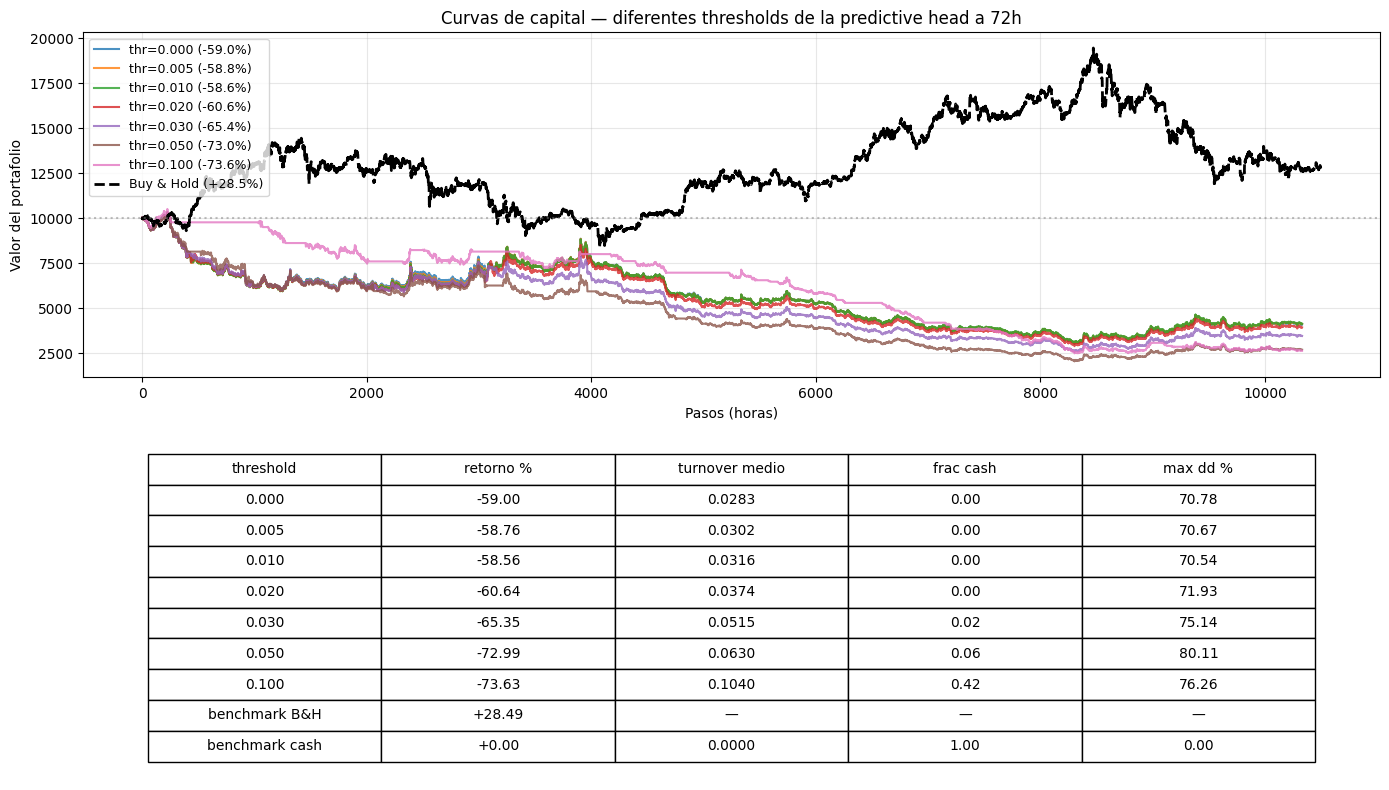


Gráfico guardado en 'predictive_backtest.png'


In [81]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import gymnasium as gym


# Si tu PredictiveHead está definido en otro lado, ajusta el import.
# Asumo que está en el mismo módulo donde entrenaste el fine-tuning.

import torch.nn as nn

class PredictiveHead(nn.Module):
    """Misma arquitectura que usaste en el fine-tuning."""
    def __init__(self, d_model=64, n_outputs=9):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.GELU(),
            nn.Linear(32, n_outputs),
        )
    
    def forward(self, cls_embedding):
        return self.head(cls_embedding)


# ============================================================
# 1. CARGAR ENCODER PREDICTIVO Y CABEZA
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Device: {device}")

# Encoder fine-tuneado (este es el cambio clave vs tu versión anterior)
encoder = MiniTradingRoberta(input_dim=12, d_model=64, n_heads=4, n_layers=3).to(device)
encoder.load_state_dict(torch.load("encoder_predictive.pth", map_location=device))
encoder.eval()
for p in encoder.parameters():
    p.requires_grad = False
print("Encoder predictivo cargado.")

# Configuración de horizontes. AJUSTA esto a lo que usaste al entrenar la cabeza.
# Para la versión de 7 horizontes:
HORIZONS = (2, 4, 8, 12, 24, 36, 72)
# Para la versión de 3 horizontes original era HORIZONS = (4, 8, 24)
# Si usaste otra, cámbiala aquí.

N_ASSETS = 3
N_OUTPUTS = len(HORIZONS) * N_ASSETS

pred_head = PredictiveHead(d_model=64, n_outputs=N_OUTPUTS).to(device)
pred_head.load_state_dict(torch.load("predictive_head.pth", map_location=device))
pred_head.eval()
print(f"PredictiveHead cargada con {N_OUTPUTS} outputs ({len(HORIZONS)} horizontes × {N_ASSETS} activos).")

# Scaler
scaler = joblib.load("scaler.pkl")


# ============================================================
# 2. CONSTRUIR ENV DE TEST CON EL ENCODER PREDICTIVO
# ============================================================
# Esto es el fix del bug: pasamos encoder_predictivo al env,
# así _precompute_embeddings usa los pesos correctos.

env_test = TradingEnv(
    prices=data_rl_test,
    encoder=encoder,        # ← encoder predictivo, no MLM
    scaler=scaler,
    transaction_cost_bps=10.0,
    initial_cash=10_000.0,
    episode_length=None,
    random_start=False,
    random_initial_portfolio=False,
)


# ============================================================
# 3. BACKTEST: estrategia de thresholding sobre predicciones a 72h
# ============================================================

def run_predictive_backtest(env, encoder, pred_head, horizons, target_horizon=72, threshold=0.02):
    """
    Usa SOLO las predicciones del horizonte indicado (default 72h) para decidir portafolio.
    Si predicción > +threshold: long en ese activo.
    Si predicción < -threshold: short.
    Si ninguna predicción supera el umbral: 100% cash.
    
    El threshold actúa como filtro de confianza: solo opera cuando la señal predicha
    es lo suficientemente grande para superar comisiones.
    """
    encoder.eval()
    pred_head.eval()
    
    device = next(encoder.parameters()).device
    
    # Localizar el índice del horizonte target en el output
    if target_horizon not in horizons:
        raise ValueError(f"target_horizon {target_horizon} no está en {horizons}")
    h_idx = list(horizons).index(target_horizon)
    idx_start = h_idx * N_ASSETS
    idx_end = idx_start + N_ASSETS
    
    obs, _ = env.reset(seed=42)
    
    historial_capital = [env._value]
    historial_turnover = []
    historial_pred = []
    historial_action = []
    
    with torch.no_grad():
        while True:
            # Extraer embedding del mercado (las primeras 64 dims de obs)
            # Esto YA es el output del encoder predictivo porque el env lo precomputó con él
            market_emb = obs[:64]
            market_tensor = torch.tensor(market_emb, dtype=torch.float32, device=device).unsqueeze(0)
            
            # Predicción para el horizonte target
            preds_all = pred_head(market_tensor).squeeze(0).cpu().numpy()
            preds_target = preds_all[idx_start:idx_end]   # (3,) predicciones por activo
            
            # Construir acción tipo símplex 7D: [long_0, long_1, long_2, short_0, short_1, short_2, cash]
            action = np.zeros(7, dtype=np.float32)
            
            long_strength = np.maximum(preds_target - threshold, 0.0)
            short_strength = np.maximum(-preds_target - threshold, 0.0)
            total = long_strength.sum() + short_strength.sum()
            
            if total > 1e-8:
                action[0:3] = long_strength / total
                action[3:6] = short_strength / total
                action[6] = 0.0
            else:
                action[6] = 1.0   # Sin señal: todo cash
            
            historial_pred.append(preds_target.copy())
            historial_action.append(action.copy())
            
            next_obs, reward, terminated, truncated, info = env.step(action)
            
            historial_capital.append(env._value)
            historial_turnover.append(info.get("turnover", 0.0))
            
            if terminated or truncated:
                break
            obs = next_obs
    
    return {
        "capital": np.array(historial_capital),
        "turnover": np.array(historial_turnover),
        "predictions": np.array(historial_pred),
        "actions": np.array(historial_action),
    }


# ============================================================
# 4. SWEEP DE THRESHOLDS
# ============================================================
# Probamos varios umbrales para ver cuál (si alguno) genera retorno positivo.

print("\n" + "="*70)
print("BACKTEST PREDICTIVO: SWEEP DE THRESHOLDS")
print("="*70)

thresholds = [0.0, 0.005, 0.01, 0.02, 0.03, 0.05, 0.10]
results = {}

for thr in thresholds:
    # Reset env para cada corrida
    env_test = TradingEnv(
        prices=data_rl_test,
        encoder=encoder,
        scaler=scaler,
        transaction_cost_bps=10.0,
        initial_cash=10_000.0,
        episode_length=None,
        random_start=False,
        random_initial_portfolio=False,
    )
    
    res = run_predictive_backtest(
        env_test, encoder, pred_head,
        horizons=HORIZONS,
        target_horizon=72,
        threshold=thr
    )
    
    capital = res["capital"]
    turnover = res["turnover"]
    actions = res["actions"]
    
    final_return = (capital[-1] / capital[0] - 1) * 100
    log_return = np.log(capital[-1] / capital[0])
    
    # Tiempo en cash: fracción de pasos donde el agente fue 100% cash
    cash_fraction = (actions[:, 6] > 0.99).mean()
    
    # Drawdown máximo
    peak = np.maximum.accumulate(capital)
    drawdowns = (peak - capital) / peak
    max_dd = drawdowns.max() * 100
    
    results[thr] = {
        "final_return": final_return,
        "log_return": log_return,
        "turnover_mean": turnover.mean(),
        "cash_fraction": cash_fraction,
        "max_drawdown": max_dd,
        "capital": capital,
    }
    
    print(f"thr={thr:.3f}: ret={final_return:+7.2f}%  "
          f"turnover={turnover.mean():.4f}  "
          f"cash_frac={cash_fraction:.2f}  "
          f"max_dd={max_dd:.2f}%")


# ============================================================
# 5. COMPARACIÓN CON BENCHMARKS
# ============================================================

# Benchmark 1: Cash todo el tiempo
print(f"\nBenchmark cash todo el tiempo: +0.00%")

# Benchmark 2: Buy and hold equiponderado (1/3 en cada activo)
def buy_and_hold(prices_df):
    close_cols = ["asset_0_close", "asset_1_close", "asset_2_close"]
    prices = prices_df[close_cols].values
    # Empezamos con 1/3 en cada activo
    initial_weights = np.array([1/3, 1/3, 1/3])
    initial_prices = prices[0]
    # Cantidad de cada activo que se compra inicialmente
    quantities = (10000 * initial_weights) / initial_prices
    # Valor del portafolio en cada paso
    portfolio_value = (prices * quantities).sum(axis=1)
    return portfolio_value

bh_capital = buy_and_hold(data_rl_test)
bh_return = (bh_capital[-1] / bh_capital[0] - 1) * 100
print(f"Benchmark buy-and-hold (1/3 cada activo): {bh_return:+.2f}%")


# ============================================================
# 6. GRÁFICOS
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Curvas de capital para cada threshold
for thr, res in results.items():
    axes[0].plot(res["capital"], label=f"thr={thr:.3f} ({res['final_return']:+.1f}%)", alpha=0.8)

axes[0].plot(bh_capital, label=f"Buy & Hold ({bh_return:+.1f}%)",
             color='black', linestyle='--', linewidth=2)
axes[0].axhline(10000, color='gray', linestyle=':', alpha=0.5)
axes[0].set_title("Curvas de capital — diferentes thresholds de la predictive head a 72h")
axes[0].set_ylabel("Valor del portafolio")
axes[0].set_xlabel("Pasos (horas)")
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(alpha=0.3)

# Resumen tabular
ax = axes[1]
ax.axis('off')
table_data = [["threshold", "retorno %", "turnover medio", "frac cash", "max dd %"]]
for thr, res in results.items():
    table_data.append([
        f"{thr:.3f}",
        f"{res['final_return']:+.2f}",
        f"{res['turnover_mean']:.4f}",
        f"{res['cash_fraction']:.2f}",
        f"{res['max_drawdown']:.2f}",
    ])
table_data.append(["benchmark B&H", f"{bh_return:+.2f}", "—", "—", "—"])
table_data.append(["benchmark cash", "+0.00", "0.0000", "1.00", "0.00"])

table = ax.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.18]*5)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.tight_layout()
plt.savefig("predictive_backtest.png", dpi=100, bbox_inches='tight')
plt.show()
print("\nGráfico guardado en 'predictive_backtest.png'")

Dataset    | Media      | Std (Vol)  | Skew (Asimetría)
Train      | 0.000019 | 0.010163 | -0.531227
Val        | 0.000033 | 0.006116 | -0.340192
Test       | 0.000011 | 0.007681 | -0.517620


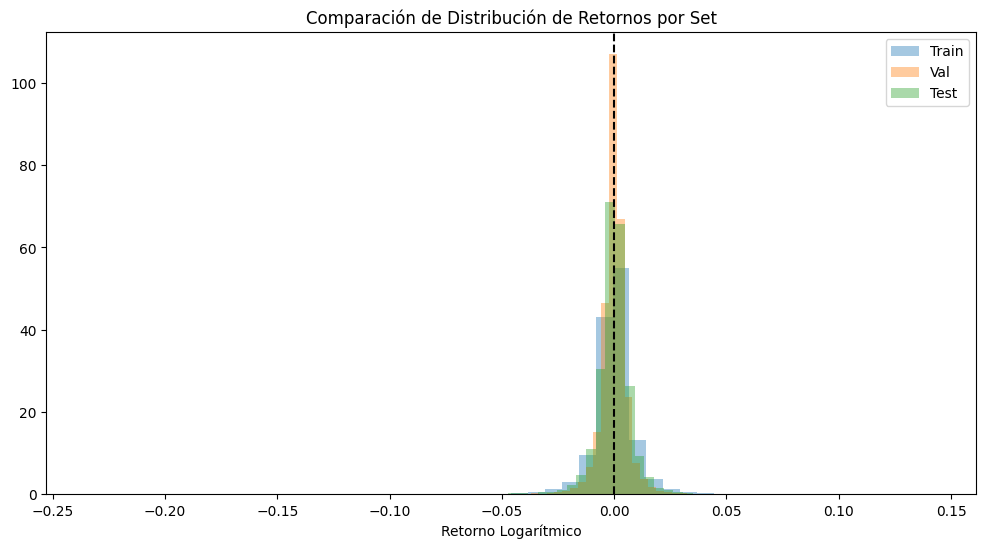

In [73]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def calculate_log_returns(df):
    # Calculamos retornos logarítmicos simples para comparar el "humor" de cada set
    # Usamos asset_0 como ejemplo, puedes iterar sobre los 3
    return np.log(df['asset_0_close'] / df['asset_0_close'].shift(1)).dropna()

# 1. Preparar los datos
returns_train = calculate_log_returns(data_train)
returns_val = calculate_log_returns(data_val)
returns_test = calculate_log_returns(data_rl_test)

# 2. Análisis Estadístico
datasets = {'Train': returns_train, 'Val': returns_val, 'Test': returns_test}

print(f"{'Dataset':<10} | {'Media':<10} | {'Std (Vol)':<10} | {'Skew (Asimetría)':<15}")
for name, data in datasets.items():
    print(f"{name:<10} | {data.mean():.6f} | {data.std():.6f} | {data.skew():.6f}")

# 3. Visualización de Distribución (Aquí veremos si los regímenes son distintos)
plt.figure(figsize=(12, 6))
for name, data in datasets.items():
    plt.hist(data, bins=50, alpha=0.4, label=name, density=True)

plt.axvline(0, color='black', linestyle='--')
plt.title("Comparación de Distribución de Retornos por Set")
plt.xlabel("Retorno Logarítmico")
plt.legend()
plt.show()

In [75]:
import torch
import numpy as np

def audit_feature_sensitivity(encoder, pred_head, window_sample, device):
    encoder.eval()
    pred_head.eval()
    
    base_window = window_sample.unsqueeze(0).to(device)
    # Obtenemos la predicción base (sin perturbar)
    with torch.no_grad():
        base_pred = pred_head(encoder(base_window)).detach().cpu().numpy()
    
    sensitivities = []
    # Definimos los nombres según tu función build_raw_stationary
    # Activo 0, 1, 2 tienen 4 features cada uno: [log_ret, amplitude, vol, tbr]
    feat_names_base = ['LogRet', 'Amplitude', 'Vol', 'TBR']
    feature_names = [f"A{a}_{n}" for a in range(3) for n in feat_names_base]
    
    print(f"{'Feature':<15} | {'Delta Predicción (Efecto en el Short)'}")
    print("-" * 50)
    
    with torch.no_grad():
        for i in range(12): 
            perturbed = base_window.clone()
            # Añadimos una perturbación pequeña (0.5 std es razonable si están escalados)
            perturbed[:, :, i] += 0.5  
            
            new_pred = pred_head(encoder(perturbed)).detach().cpu().numpy()
            # Si delta es negativo, significa que al aumentar esa feature, 
            # el modelo predice una caída más fuerte (más bajista)
            delta = (new_pred - base_pred).mean() 
            sensitivities.append(delta)
            print(f"{feature_names[i]:<15} | {delta:+.6f}")
            
    return sensitivities, feature_names

# Ejecución
sample_window, _, _ = next(iter(loader_val))
sens, names = audit_feature_sensitivity(encoder, pred_head, sample_window[0], device)

Feature         | Delta Predicción (Efecto en el Short)
--------------------------------------------------
A0_LogRet       | +0.002996
A0_Amplitude    | +0.000387
A0_Vol          | +0.009465
A0_TBR          | -0.002502
A1_LogRet       | +0.007146
A1_Amplitude    | -0.024013
A1_Vol          | +0.021303
A1_TBR          | -0.003519
A2_LogRet       | -0.002029
A2_Amplitude    | -0.006624
A2_Vol          | +0.004719
A2_TBR          | +0.010452


In [80]:
class TradingEnv(BaseTradingEnv):
    """
    Entorno de trading con acción continua de 7 dimensiones (símplex Dirichlet).
    Estado = embedding del mercado (64D, frozen MLM) ++ portafolio actual (4D) = 68D.

    El constructor recibe el encoder y el scaler ya entrenados. El environment
    NO los entrena, solo los usa para producir embeddings frozen.
    """

    OBS_DIM    = 68
    ACTION_DIM = 7
    LOOKBACK   = 168
    EMB_DIM    = 64

    def __init__(
        self,
        prices: pd.DataFrame,
        encoder: MiniTradingRoberta,
        scaler: StandardScaler,
        transaction_cost_bps: float = 10.0,
        initial_cash: float = 10_000.0,
        embed_batch_size: int = 256,
        episode_length: int | None = None,   # None = trayectoria completa (eval)
        random_start: bool = False,          # True para train, False para eval
        random_initial_portfolio: bool = False,
    ):
        super().__init__(prices, transaction_cost_bps, initial_cash)

        self._lookback = self.LOOKBACK
        self.episode_length = episode_length
        self.random_start = random_start
        self.random_initial_portfolio = random_initial_portfolio
        self.device = next(encoder.parameters()).device

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.OBS_DIM,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=0.0, high=1.0, shape=(self.ACTION_DIM,), dtype=np.float32
        )

        self._latents, self._valid_t_min = self._precompute_embeddings(
            prices, encoder, scaler, embed_batch_size
        )
        # Ajustamos el lookback efectivo al primer timestep con embedding válido
        self._lookback = max(self._lookback, self._valid_t_min)

        self._rng = np.random.default_rng()
        self._episode_end_t = None   # se setea en reset()

    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self._rng = np.random.default_rng(seed)
        # gym.Env reset boilerplate (sin invocar el reset del padre que fija _t)
        gym.Env.reset(self, seed=seed)

        T = len(self.prices)
        if self.random_start:
            ep_len = self.episode_length or (T - self._lookback - 1)
            max_start = T - ep_len - 1
            self._t = int(self._rng.integers(self._lookback, max_start + 1))
            self._episode_end_t = self._t + ep_len
        else:
            self._t = self._lookback
            self._episode_end_t = T - 1

        if self.random_initial_portfolio:
            # Sampleamos del símplex 7D uniforme y mapeamos a portafolio
            alpha = np.ones(7, dtype=np.float32)
            p = self._rng.dirichlet(alpha).astype(np.float32)
            w = np.array([
                p[0] - p[3], p[1] - p[4], p[2] - p[5],
            ], dtype=np.float32)
            cash = np.float32(1.0) - w.sum()
            self._weights = np.append(w, cash).astype(np.float32)
        else:
            self._weights = np.array([0., 0., 0., 1.], dtype=np.float32)

        self._value = float(self.initial_cash)
        return self._obs(), {}

    def step(self, action):
        obs, reward, terminated, truncated, info = super().step(action)
        # Cortamos el episodio si llegamos al final de la ventana de RL,
        # incluso si no se acabó la serie completa
        if self._episode_end_t is not None and self._t >= self._episode_end_t:
            truncated = True
        return obs, reward, terminated, truncated, info

    # ----- Embeddings -----

    def _precompute_embeddings(self, prices_df, encoder, scaler, batch_size):
        """
        Calcula self._latents[t] = embedding CLS para la ventana de mercado
        que termina (exclusivo) en el índice t del DataFrame de precios original.

        Devuelve también el primer t para el cual el embedding es válido.
        """
        # 1. Construir features estandarizadas (esto pierde la primera fila por dropna)
        # OPCIÓN 1: Si es una tupla, quédate solo con el DataFrame (posición 0)
        resultado = build_raw_stationary(prices_df, scaler=scaler, fit=False)
        
        if isinstance(resultado, tuple):
            features = resultado[0] # El DataFrame es el primer elemento
        else:
            features = resultado
            
        feature_vals = features.values.astype(np.float32)

        # 2. Mapear índices: feature.index ⊂ prices_df.index (faltan filas del comienzo)
        #    Para cada t del DataFrame de precios, dónde cae en features.
        price_index = prices_df.index
        feat_index  = features.index
        feat_pos = pd.Series(np.arange(len(feat_index)), index=feat_index)

        T_prices = len(price_index)
        latents = np.zeros((T_prices, self.EMB_DIM), dtype=np.float32)
        valid_mask = np.zeros(T_prices, dtype=bool)

        encoder.eval()

        # 3. Recolectar ventanas válidas (donde haya suficiente historia de features)
        windows, t_targets = [], []
        for t in range(T_prices):
            ts = price_index[t]
            if ts not in feat_pos.index:
                continue   # esta fila del precio quedó fuera de features por dropna
            pos = int(feat_pos.loc[ts])
            if pos < self._lookback:
                continue   # no hay suficiente historia hacia atrás
            window = feature_vals[pos - self._lookback : pos]   # (168, 12)
            windows.append(window)
            t_targets.append(t)

        if not windows:
            raise RuntimeError("No hay ventanas válidas. ¿lookback demasiado grande?")

        # 4. Forward por batches
        with torch.no_grad():
            for i in range(0, len(windows), batch_size):
                batch = np.stack(windows[i:i + batch_size], axis=0)   # (B, 168, 12)
                tb = torch.from_numpy(batch).to(self.device)
                emb = encoder(tb, is_mlm=False).cpu().numpy()         # (B, 64)
                for j, t_idx in enumerate(t_targets[i:i + batch_size]):
                    latents[t_idx] = emb[j]
                    valid_mask[t_idx] = True

        valid_t_min = int(np.argmax(valid_mask))   # primer índice con embedding
        return latents, valid_t_min

    # ----- Abstract methods -----

    def _obs(self) -> np.ndarray:
        market_emb = self._latents[self._t]                   # (64,)
        portfolio  = self._weights.astype(np.float32)         # (4,)
        return np.concatenate([market_emb, portfolio], axis=0).astype(np.float32)

    def _weights_from_action(self, action: np.ndarray) -> np.ndarray:
        """
        action ∈ símplex 7D: [long_0, long_1, long_2, short_0, short_1, short_2, cash]
        Mapeo a portafolio (4,): [w_0, w_1, w_2, cash_physical]
        """
        action = np.asarray(action, dtype=np.float32)
        w = np.array([
            action[0] - action[3],
            action[1] - action[4],
            action[2] - action[5],
        ], dtype=np.float32)
        cash = np.float32(1.0) - w.sum()
        # Por aritmética del símplex: cash >= 0 y sum total = 1. No clipear.
        return np.append(w, cash).astype(np.float32)

    def _reward(self, prev_value: float, curr_value: float) -> float:
        # Log-return puro. Si quieres añadir penalización de drawdown o turnover
        # más adelante, este es el lugar.
        return math.log(curr_value / prev_value)

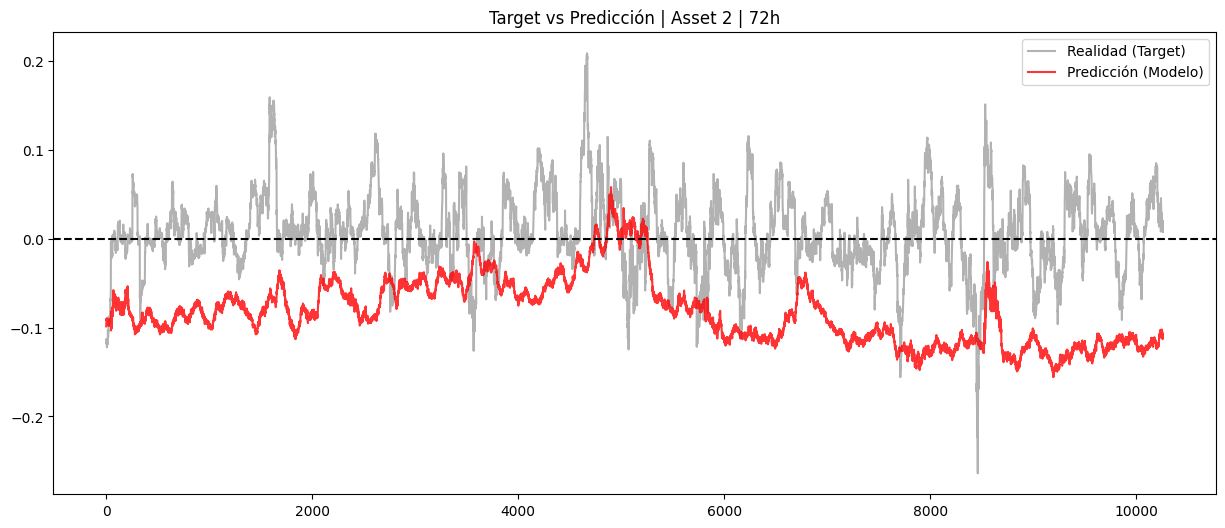

In [69]:
import matplotlib.pyplot as plt

def plot_target_vs_prediction(env_loader, encoder, pred_head, asset_idx=0, horizon_idx=6):
    """
    Compara visualmente los targets reales con las predicciones del modelo.
    asset_idx: 0, 1 o 2.
    horizon_idx: 0 a 6 (índice en tu tupla HORIZONS).
    """
    encoder.eval()
    pred_head.eval()
    
    all_targets = []
    all_preds = []
    
    device = next(encoder.parameters()).device
    
    with torch.no_grad():
        for windows, _, targets in env_loader:
            windows = windows.to(device)
            targets = targets.to(device)
            
            # Forward pass
            cls = encoder(windows, is_mlm=False)
            preds = pred_head(cls)
            
            # Seleccionar el activo y horizonte específico
            # Tu target shape es (N, 21), donde 21 = 7 horizontes * 3 activos
            # La fórmula para encontrar el índice es: horizon_idx * 3 + asset_idx
            idx = horizon_idx * 3 + asset_idx
            
            all_targets.append(targets[:, idx].cpu().numpy())
            all_preds.append(preds[:, idx].cpu().numpy())
            
    # Concatenar todo en una línea de tiempo
    targets_vec = np.concatenate(all_targets)
    preds_vec = np.concatenate(all_preds)
    
    # Graficar
    plt.figure(figsize=(15, 6))
    plt.plot(targets_vec, label='Realidad (Target)', alpha=0.6, color='gray')
    plt.plot(preds_vec, label='Predicción (Modelo)', alpha=0.8, color='red')
    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"Target vs Predicción | Asset {asset_idx} | 72h")
    plt.legend()
    plt.show()

# Ejecución: Comparar el Asset 1 (el que mejor correlación tenía)
plot_target_vs_prediction(loader_val, encoder, pred_head, asset_idx=2, horizon_idx=6)

Ejecutando Backtest Ingenuo (Umbral = 2.0% de señal mínima)...
Retorno Final: -23.07%
Turnover Medio por Paso: 0.1040


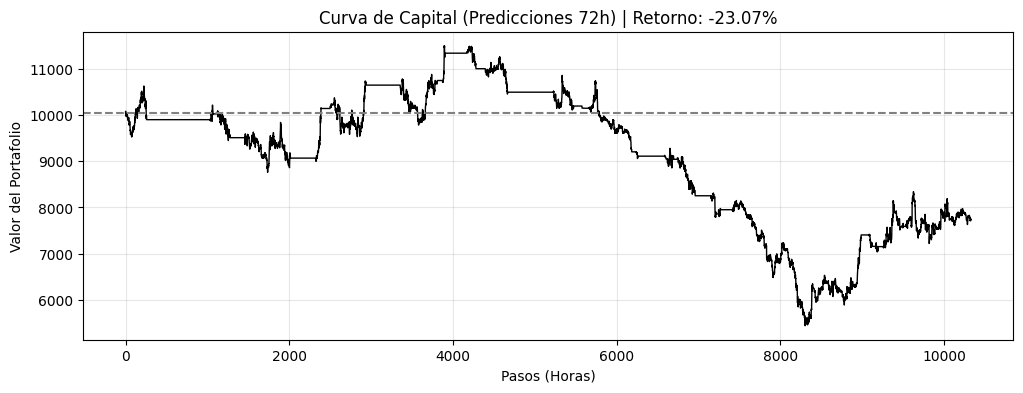

In [72]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# BACKTEST: Estrategia de Thresholding a 72h usando PredictiveHead
# =============================================================================

def run_predictive_backtest(env, encoder, pred_head, threshold=0.02):
    """
    Evalúa la capacidad de ganar dinero usando SOLO las predicciones a 72h.
    threshold: El umbral mínimo de retorno esperado para ejecutar una orden.
               Si es 0.02, el modelo exige esperar una subida/caída > 2% para operar,
               ignorando el ruido y ahorrando comisiones (10 bps).
    """
    encoder.eval()
    pred_head.eval()
    
    device = next(encoder.parameters()).device
    obs, _ = env.reset(seed=42)
    
    historial_capital = []
    historial_turnover = []
    
    # Índices del horizonte a 72h en la salida de 21D
    # HORIZONS = (2, 4, 8, 12, 24, 36, 72) -> 7 horizontes * 3 activos = 21 outputs
    # Los últimos 3 índices (18, 19, 20) corresponden a 72h para asset 0, 1, 2
    idx_72h_start = 6 * 3 
    
    with torch.no_grad():
        while True:
            # 1. Extraer el mercado de la observación
            # obs en TradingEnv es [mercado_64D, portafolio_4D]
            market_state = obs[:64]
            market_tensor = torch.tensor(market_state, dtype=torch.float32, device=device).unsqueeze(0)
            
            # 2. Obtener las predicciones crudas
            preds = pred_head(market_tensor).squeeze(0).cpu().numpy()
            
            # 3. Aislar las predicciones a 72 horas para los 3 activos
            preds_72h = preds[idx_72h_start : idx_72h_start + 3]
            
            # 4. LÓGICA INGENUA DE TRADING (Thresholding)
            # action = [long_0, long_1, long_2, short_0, short_1, short_2, cash]
            action = np.zeros(7, dtype=np.float32)
            
            # Buscamos señales fuertes que superen el umbral
            long_signals = np.maximum(preds_72h - threshold, 0)
            short_signals = np.maximum(-preds_72h - threshold, 0)
            
            fuerza_total = np.sum(long_signals) + np.sum(short_signals)
            
            if fuerza_total > 0:
                # Normalizamos las señales para usar el 100% del capital
                action[0:3] = long_signals / fuerza_total
                action[3:6] = short_signals / fuerza_total
                action[6] = 0.0 # Cero intención de cash, estamos apostando
            else:
                # Si ninguna predicción supera el umbral, nos refugiamos para no pagar comisiones
                action[6] = 1.0 # 100% Cash
                
            # 5. Ejecutar la acción en el entorno
            next_obs, reward, terminated, truncated, info = env.step(action)
            
            historial_capital.append(env._value)
            historial_turnover.append(info.get("turnover", 0.0))
            
            if terminated or truncated:
                break
                
            obs = next_obs
            
    return historial_capital, historial_turnover

# =============================================================================
# EJECUCIÓN
# =============================================================================

# Instanciamos el entorno solo con los datos de RL Test (Validación fuera de muestra)
# random_start=False para que empiece desde el día 1 de la serie y la recorra linealmente
env_test = TradingEnv(
    prices=data_rl_test, 
    encoder=encoder, 
    scaler=scaler, 
    transaction_cost_bps=0,
    random_start=False 
)

print("Ejecutando Backtest Ingenuo (Umbral = 2.0% de señal mínima)...")
capital, turnover = run_predictive_backtest(env_test, encoder, pred_head, threshold=0.1)

retorno_total = (capital[-1] / capital[0] - 1) * 100
turnover_medio = np.mean(turnover)

print(f"Retorno Final: {retorno_total:+.2f}%")
print(f"Turnover Medio por Paso: {turnover_medio:.4f}")

# Gráfico
plt.figure(figsize=(12, 4))
plt.plot(capital, color='black', linewidth=1)
plt.axhline(capital[0], color='gray', linestyle='dashed')
plt.title(f"Curva de Capital (Predicciones 72h) | Retorno: {retorno_total:+.2f}%")
plt.xlabel("Pasos (Horas)")
plt.ylabel("Valor del Portafolio")
plt.grid(alpha=0.3)
plt.show()

In [44]:
# Diagnóstico del scaler de targets y separación train/val
print(f"\n── Diagnóstico de targets ──")
print(f"Targets train: mean={ds_train.targets[~torch.isnan(ds_train.targets)].mean():.5f}")
print(f"Targets train: std={ds_train.targets[~torch.isnan(ds_train.targets)].std():.5f}")
print(f"Targets val:   mean={ds_val.targets[~torch.isnan(ds_val.targets)].mean():.5f}")
print(f"Targets val:   std={ds_val.targets[~torch.isnan(ds_val.targets)].std():.5f}")

# Inspeccionar predicciones reales vs targets en val
encoder.eval()
pred_head.eval()
preds_all = []
targs_all = []
with torch.no_grad():
    for windows, targets in loader_val:
        windows = windows.to(device)
        targets = targets.to(device)
        valid = ~torch.isnan(targets).any(dim=1)
        if valid.sum() == 0: continue
        cls = encoder(windows[valid], is_mlm=False)
        pred = pred_head(cls)
        preds_all.append(pred.cpu().numpy())
        targs_all.append(targets[valid].cpu().numpy())

preds_all = np.concatenate(preds_all)
targs_all = np.concatenate(targs_all)

print(f"\n── Predicciones vs realidad en val ──")
print(f"Pred mean: {preds_all.mean():.5f}, std: {preds_all.std():.5f}")
print(f"Real mean: {targs_all.mean():.5f}, std: {targs_all.std():.5f}")
print(f"Correlación pred-real por activo:")
for i in range(3):
    corr = np.corrcoef(preds_all[:, i], targs_all[:, i])[0, 1]
    print(f"  asset_{i}: {corr:+.4f}")


── Diagnóstico de targets ──
Targets train: mean=0.00083
Targets train: std=0.04795
Targets val:   mean=0.00159
Targets val:   std=0.02767

── Predicciones vs realidad en val ──
Pred mean: -0.00345, std: 0.00279
Real mean: 0.00168, std: 0.02788
Correlación pred-real por activo:
  asset_0: +0.0882
  asset_1: +0.0704
  asset_2: +0.0558


In [ ]:
#import joblib; joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [14]:
# =============================================================================
# YOUR FILE — agent.py
# Implements TradingEnv (continuous action) and Agent (PPO with Dirichlet policy).
# =============================================================================

import math
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import gymnasium as gym
from gymnasium import spaces
from sklearn.preprocessing import StandardScaler

from src.env import BaseTradingEnv
from src.base import BaseAgent


# ── Encoder MLM (frozen, copia de la arquitectura entrenada) ─────────────────

class MiniTradingRoberta(nn.Module):
    """
    Copia exacta de la arquitectura usada en el pretraining MLM.
    Solo se usa para cargar los pesos y hacer forward en modo eval.
    """
    def __init__(self, input_dim=12, d_model=64, n_heads=4, n_layers=2, max_seq_len=170):
        super().__init__()
        self.d_model = d_model
        self.feature_projection = nn.Linear(input_dim, d_model)
        self.cls_token  = nn.Parameter(torch.randn(1, 1, d_model))
        self.sep_token  = nn.Parameter(torch.randn(1, 1, d_model))
        self.mask_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.pad_token  = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embedding = nn.Parameter(torch.randn(1, max_seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=128,
            dropout=0.1, activation="gelu", batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.mlm_head = nn.Linear(d_model, input_dim)

    def forward(self, x, padding_mask=None, mlm_mask=None, is_mlm=False):
        B, seq_len, _ = x.shape
        x_emb = self.feature_projection(x)
        if padding_mask is not None:
            x_emb = torch.where(padding_mask.unsqueeze(-1), self.pad_token, x_emb)
        if is_mlm and mlm_mask is not None:
            x_emb = torch.where(mlm_mask.unsqueeze(-1), self.mask_token, x_emb)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        sep_tokens = self.sep_token.expand(B, -1, -1)
        sequence = torch.cat((cls_tokens, x_emb, sep_tokens), dim=1)
        sequence = sequence + self.pos_embedding[:, :sequence.size(1), :]
        if padding_mask is not None:
            cls_pad = torch.zeros((B, 1), dtype=torch.bool, device=x.device)
            sep_pad = torch.zeros((B, 1), dtype=torch.bool, device=x.device)
            transformer_pad_mask = torch.cat((cls_pad, padding_mask, sep_pad), dim=1)
        else:
            transformer_pad_mask = None
        out = self.transformer(sequence, src_key_padding_mask=transformer_pad_mask)
        if is_mlm:
            return self.mlm_head(out[:, 1:-1, :])
        return out[:, 0, :]   # CLS embedding (B, d_model)


# ── Feature builder (la misma del MLM, para alinear el preprocesamiento) ─────

def build_raw_stationary(data: pd.DataFrame, scaler: StandardScaler, fit: bool = False):
    """
    Aplica la misma transformación usada en el pretraining MLM.
    El scaler debe venir del fit hecho con los datos de training.
    """
    frames = []
    assets = ["asset_0", "asset_1", "asset_2"]
    for asset in assets:
        close = data[f"{asset}_close"]
        high  = data[f"{asset}_high"]
        low   = data[f"{asset}_low"]
        vol   = data[f"{asset}_volume"]
        tbr   = data[f"{asset}_taker_buy_ratio"]
        log_ret   = np.log(close / close.shift(1))
        amplitude = (high - low) / close.shift(1)
        frames.append(pd.DataFrame({
            f"{asset}_log_ret":    log_ret,
            f"{asset}_amplitude":  amplitude,
            f"{asset}_vol":        vol,
            f"{asset}_tbr":        tbr,
        }))
    X = pd.concat(frames, axis=1).dropna()
    if fit:
        scaler.fit(X.values)
    X_scaled = pd.DataFrame(scaler.transform(X.values), index=X.index, columns=X.columns)
    return X_scaled


# ── Environment ──────────────────────────────────────────────────────────────

class TradingEnv(BaseTradingEnv):
    """
    Entorno de trading con acción continua de 7 dimensiones (símplex Dirichlet).
    Estado = embedding del mercado (64D, frozen MLM) ++ portafolio actual (4D) = 68D.

    El constructor recibe el encoder y el scaler ya entrenados. El environment
    NO los entrena, solo los usa para producir embeddings frozen.
    """

    OBS_DIM    = 68
    ACTION_DIM = 7
    LOOKBACK   = 168
    EMB_DIM    = 64

    def __init__(
        self,
        prices: pd.DataFrame,
        encoder: MiniTradingRoberta,
        scaler: StandardScaler,
        transaction_cost_bps: float = 10.0,
        initial_cash: float = 10_000.0,
        embed_batch_size: int = 256,
        episode_length: int | None = None,   # None = trayectoria completa (eval)
        random_start: bool = False,          # True para train, False para eval
        random_initial_portfolio: bool = False,
    ):
        super().__init__(prices, transaction_cost_bps, initial_cash)

        self._lookback = self.LOOKBACK
        self.episode_length = episode_length
        self.random_start = random_start
        self.random_initial_portfolio = random_initial_portfolio
        self.device = next(encoder.parameters()).device

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.OBS_DIM,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=0.0, high=1.0, shape=(self.ACTION_DIM,), dtype=np.float32
        )

        self._latents, self._valid_t_min = self._precompute_embeddings(
            prices, encoder, scaler, embed_batch_size
        )
        # Ajustamos el lookback efectivo al primer timestep con embedding válido
        self._lookback = max(self._lookback, self._valid_t_min)

        self._rng = np.random.default_rng()
        self._episode_end_t = None   # se setea en reset()

    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self._rng = np.random.default_rng(seed)
        # gym.Env reset boilerplate (sin invocar el reset del padre que fija _t)
        gym.Env.reset(self, seed=seed)

        T = len(self.prices)
        if self.random_start:
            ep_len = self.episode_length or (T - self._lookback - 1)
            max_start = T - ep_len - 1
            self._t = int(self._rng.integers(self._lookback, max_start + 1))
            self._episode_end_t = self._t + ep_len
        else:
            self._t = self._lookback
            self._episode_end_t = T - 1

        if self.random_initial_portfolio:
            # Sampleamos del símplex 7D uniforme y mapeamos a portafolio
            alpha = np.ones(7, dtype=np.float32)
            p = self._rng.dirichlet(alpha).astype(np.float32)
            w = np.array([
                p[0] - p[3], p[1] - p[4], p[2] - p[5],
            ], dtype=np.float32)
            cash = np.float32(1.0) - w.sum()
            self._weights = np.append(w, cash).astype(np.float32)
        else:
            self._weights = np.array([0., 0., 0., 1.], dtype=np.float32)

        self._value = float(self.initial_cash)
        return self._obs(), {}

    def step(self, action):
        obs, reward, terminated, truncated, info = super().step(action)
        # Cortamos el episodio si llegamos al final de la ventana de RL,
        # incluso si no se acabó la serie completa
        if self._episode_end_t is not None and self._t >= self._episode_end_t:
            truncated = True
        return obs, reward, terminated, truncated, info

    # ----- Embeddings -----

    def _precompute_embeddings(self, prices_df, encoder, scaler, batch_size):
        """
        Calcula self._latents[t] = embedding CLS para la ventana de mercado
        que termina (exclusivo) en el índice t del DataFrame de precios original.

        Devuelve también el primer t para el cual el embedding es válido.
        """
        # 1. Construir features estandarizadas (esto pierde la primera fila por dropna)
        features = build_raw_stationary(prices_df, scaler=scaler, fit=False)
        feature_vals = features.values.astype(np.float32)   # (T_feat, 12)

        # 2. Mapear índices: feature.index ⊂ prices_df.index (faltan filas del comienzo)
        #    Para cada t del DataFrame de precios, dónde cae en features.
        price_index = prices_df.index
        feat_index  = features.index
        feat_pos = pd.Series(np.arange(len(feat_index)), index=feat_index)

        T_prices = len(price_index)
        latents = np.zeros((T_prices, self.EMB_DIM), dtype=np.float32)
        valid_mask = np.zeros(T_prices, dtype=bool)

        encoder.eval()

        # 3. Recolectar ventanas válidas (donde haya suficiente historia de features)
        windows, t_targets = [], []
        for t in range(T_prices):
            ts = price_index[t]
            if ts not in feat_pos.index:
                continue   # esta fila del precio quedó fuera de features por dropna
            pos = int(feat_pos.loc[ts])
            if pos < self._lookback:
                continue   # no hay suficiente historia hacia atrás
            window = feature_vals[pos - self._lookback : pos]   # (168, 12)
            windows.append(window)
            t_targets.append(t)

        if not windows:
            raise RuntimeError("No hay ventanas válidas. ¿lookback demasiado grande?")

        # 4. Forward por batches
        with torch.no_grad():
            for i in range(0, len(windows), batch_size):
                batch = np.stack(windows[i:i + batch_size], axis=0)   # (B, 168, 12)
                tb = torch.from_numpy(batch).to(self.device)
                emb = encoder(tb, is_mlm=False).cpu().numpy()         # (B, 64)
                for j, t_idx in enumerate(t_targets[i:i + batch_size]):
                    latents[t_idx] = emb[j]
                    valid_mask[t_idx] = True

        valid_t_min = int(np.argmax(valid_mask))   # primer índice con embedding
        return latents, valid_t_min

    # ----- Abstract methods -----

    def _obs(self) -> np.ndarray:
        market_emb = self._latents[self._t]                   # (64,)
        portfolio  = self._weights.astype(np.float32)         # (4,)
        return np.concatenate([market_emb, portfolio], axis=0).astype(np.float32)

    def _weights_from_action(self, action: np.ndarray) -> np.ndarray:
        """
        action ∈ símplex 7D: [long_0, long_1, long_2, short_0, short_1, short_2, cash]
        Mapeo a portafolio (4,): [w_0, w_1, w_2, cash_physical]
        """
        action = np.asarray(action, dtype=np.float32)
        w = np.array([
            action[0] - action[3],
            action[1] - action[4],
            action[2] - action[5],
        ], dtype=np.float32)
        cash = np.float32(1.0) - w.sum()
        # Por aritmética del símplex: cash >= 0 y sum total = 1. No clipear.
        return np.append(w, cash).astype(np.float32)

    def _reward(self, prev_value: float, curr_value: float) -> float:
        # Log-return puro. Si quieres añadir penalización de drawdown o turnover
        # más adelante, este es el lugar.
        return math.log(curr_value / prev_value)
    
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Dirichlet


# ── Redes ────────────────────────────────────────────────────────────────────

class ActorCritic(nn.Module):
    """
    Actor: emite los 7 α de la Dirichlet.
    Critic: emite V(s) escalar.
    Backbones independientes (decisión justificada para evitar interferencia).
    """
    def __init__(self, obs_dim: int = 68, hidden: int = 128, action_dim: int = 7):
        super().__init__()
        self.actor_trunk = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
        )
        self.actor_head = nn.Linear(hidden, action_dim)

        self.critic_trunk = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
        )
        self.critic_head = nn.Linear(hidden, 1)

        nn.init.constant_(self.actor_head.bias, 1.0)


    def get_alpha(self, obs):
        h = self.actor_trunk(obs)
        # softplus + epsilon garantiza α > 0 y evita degeneraciones en 0
        return F.softplus(self.actor_head(h)) + 1.0 #+ 1e-3

    def get_value(self, obs):
        return self.critic_head(self.critic_trunk(obs)).squeeze(-1)

    def sample_action(self, obs):
        """Para rollout: muestra acción estocástica + log_prob + valor."""
        alpha = self.get_alpha(obs)
        dist = Dirichlet(alpha)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        value = self.get_value(obs)
        return action, log_prob, value

    def evaluate_actions(self, obs, actions):
        """Para optimización: log_prob nueva, entropía y valor sobre acciones del buffer."""
        alpha = self.get_alpha(obs)
        dist = Dirichlet(alpha)
        log_prob = dist.log_prob(actions)
        entropy = dist.entropy()
        value = self.get_value(obs)
        return log_prob, entropy, value


# ── Rollout buffer ───────────────────────────────────────────────────────────

class RolloutBuffer:
    def __init__(self, size, obs_dim, action_dim, device):
        self.size, self.device = size, device
        self.obs       = torch.zeros((size, obs_dim),    device=device)
        self.actions   = torch.zeros((size, action_dim), device=device)
        self.log_probs = torch.zeros(size,               device=device)
        self.rewards   = torch.zeros(size,               device=device)
        self.values    = torch.zeros(size,               device=device)
        self.dones     = torch.zeros(size,               device=device)
        self.ptr = 0

    def add(self, obs, action, log_prob, reward, value, done):
        i = self.ptr
        self.obs[i]       = obs
        self.actions[i]   = action
        self.log_probs[i] = log_prob
        self.rewards[i]   = reward
        self.values[i]    = value
        self.dones[i]     = float(done)
        self.ptr += 1

    def compute_gae(self, last_value, gamma=0.99, lam=0.95):
        """Generalized Advantage Estimation."""
        advantages = torch.zeros(self.size, device=self.device)
        gae = 0.0
        for t in reversed(range(self.size)):
            next_value = last_value if t == self.size - 1 else self.values[t + 1]
            next_non_terminal = 1.0 - self.dones[t]
            delta = self.rewards[t] + gamma * next_value * next_non_terminal - self.values[t]
            gae = delta + gamma * lam * next_non_terminal * gae
            advantages[t] = gae
        returns = advantages + self.values
        return advantages, returns


# ── Agente ───────────────────────────────────────────────────────────────────

class Agent(BaseAgent):

    def __init__(self, obs_dim: int = 68, n_actions: int = 7):
        super().__init__(obs_dim, n_actions)
        self.device = torch.device(
            "cuda" if torch.cuda.is_available() else
            "mps"  if torch.backends.mps.is_available() else
            "cpu"
        )
        self.ac = ActorCritic(obs_dim, hidden=128, action_dim=n_actions).to(self.device)
        self.optimizer = torch.optim.Adam(self.ac.parameters(), lr=3e-4)

        # Hiperparámetros PPO
        self.gamma       = 0.99
        self.lam         = 0.95
        self.clip_eps    = 0.2
        self.epochs_ppo  = 10
        self.minibatch   = 64
        self.rollout_len = 2048
        self.c_value     = 0.5
        self.c_entropy   = 0.0001
        self.grad_clip   = 0.5

    # ----- Entrenamiento -----

    def train(self, env, n_steps: int = 500_000, val_env=None, eval_every: int = 20):
        n_iters = n_steps // self.rollout_len
        obs, _ = env.reset()
        obs = torch.from_numpy(obs).to(self.device)

        best_val_return = -float("inf")
        episode_returns = []   # para logging
        running_return = 0.0



        for it in range(n_iters):
            buffer = RolloutBuffer(self.rollout_len, env.OBS_DIM, env.ACTION_DIM, self.device)
            self.ac.eval()

            # ◄────── PUNTO 1: inicializar acumuladores al inicio de cada iteración
            turnover_acc = 0.0
            turnover_count = 0

            # ---------- ROLLOUT ----------
            for _ in range(self.rollout_len):
                with torch.no_grad():
                    action, log_prob, value = self.ac.sample_action(obs.unsqueeze(0))
                    action  = action.squeeze(0)
                    log_prob = log_prob.squeeze(0)
                    value    = value.squeeze(0)

                next_obs, reward, terminated, truncated, info = env.step(action.cpu().numpy())
                done = terminated or truncated

                buffer.add(obs, action, log_prob, reward, value, done)
                running_return += reward

                # ◄────── PUNTO 2: acumular turnover de cada step
                turnover_acc += info.get("turnover", 0.0)
                turnover_count += 1

                if done:
                    episode_returns.append(running_return)
                    running_return = 0.0
                    next_obs, _ = env.reset()

                obs = torch.from_numpy(next_obs).to(self.device)

            # ---------- GAE ----------
            with torch.no_grad():
                last_value = self.ac.get_value(obs.unsqueeze(0)).squeeze(0)
            advantages, returns = buffer.compute_gae(last_value, self.gamma, self.lam)
            # Normalización de ventajas (estándar en PPO)
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

            # ---------- OPTIMIZACIÓN ----------
            self.ac.train()
            idx = np.arange(self.rollout_len)
            for _ in range(self.epochs_ppo):
                np.random.shuffle(idx)
                for start in range(0, self.rollout_len, self.minibatch):
                    mb = idx[start:start + self.minibatch]
                    mb_obs   = buffer.obs[mb]
                    mb_acts  = buffer.actions[mb]
                    mb_old_lp = buffer.log_probs[mb]
                    mb_adv   = advantages[mb]
                    mb_ret   = returns[mb]

                    new_lp, entropy, value = self.ac.evaluate_actions(mb_obs, mb_acts)

                    ratio = torch.exp(new_lp - mb_old_lp)
                    surr1 = ratio * mb_adv
                    surr2 = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * mb_adv
                    actor_loss   = -torch.min(surr1, surr2).mean()
                    value_loss   = F.mse_loss(value, mb_ret)
                    entropy_loss = -entropy.mean()

                    loss = actor_loss + self.c_value * value_loss + self.c_entropy * entropy_loss

                    self.optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(self.ac.parameters(), self.grad_clip)
                    self.optimizer.step()

            # ---------- LOGGING ----------
            recent = episode_returns[-20:] if episode_returns else [0.0]
            mean_turnover = turnover_acc / turnover_count   # ◄── PUNTO 3a: calcular promedio
            print(
                f"[Iter {it+1}/{n_iters}] "
                f"steps={(it+1)*self.rollout_len} "
                f"mean_ep_return={np.mean(recent):+.4f} "
                f"turnover={mean_turnover:.3f} "          # ◄── PUNTO 3b: añadir al print
                f"actor_loss={actor_loss.item():+.4f} "
                f"value_loss={value_loss.item():.4f} "
                f"entropy={(-entropy_loss.item()):.3f}"
            )

            # ---------- EVALUACIÓN ----------
            if val_env is not None and (it + 1) % eval_every == 0:
                val_return = self.evaluate(val_env)
                print(f"  └─ val_return = {val_return:+.4f}")
                if val_return > best_val_return:
                    best_val_return = val_return
                    torch.save(self.ac.state_dict(), "best_agent.pth")
                    print(f"     ¡Nuevo mejor agente guardado! ({val_return:+.4f})")

        # Restaurar mejor versión al final
        if val_env is not None and Path("best_agent.pth").exists():
            self.ac.load_state_dict(torch.load("best_agent.pth"))
            print(f"\nPesos óptimos restaurados (val_return = {best_val_return:+.4f}).")

    # ----- Evaluación determinista en val/test -----

    @torch.no_grad()
    def evaluate(self, env):
        self.ac.eval()
        obs, _ = env.reset()
        obs = torch.from_numpy(obs).to(self.device)
        total_return = 0.0
        while True:
            alpha = self.ac.get_alpha(obs.unsqueeze(0))
            action = (alpha / alpha.sum(dim=-1, keepdim=True)).squeeze(0)   # media de Dirichlet
            next_obs, reward, terminated, truncated, _ = env.step(action.cpu().numpy())
            total_return += reward
            if terminated or truncated:
                break
            obs = torch.from_numpy(next_obs).to(self.device)
        return total_return

    # ----- Inferencia (act) -----

    @torch.no_grad()
    def act(self, obs: np.ndarray) -> np.ndarray:
        """
        Modo evaluación: acción determinista (media de la Dirichlet).
        Devuelve un vector 7D que el environment mapea a 4 pesos.
        """
        self.ac.eval()
        obs_t = torch.from_numpy(obs).to(self.device).unsqueeze(0)
        alpha = self.ac.get_alpha(obs_t)
        action = (alpha / alpha.sum(dim=-1, keepdim=True)).squeeze(0)
        return action.cpu().numpy()

In [18]:
# Carga el encoder y el scaler
encoder = MiniTradingRoberta(input_dim=12, d_model=64, n_heads=4, n_layers=3).to(device)
encoder.load_state_dict(torch.load("mejor_modelo_mlm.pth", map_location=device))
encoder.eval()
for p in encoder.parameters():
    p.requires_grad = False

import joblib
scaler = joblib.load("scaler.pkl")

# Environments
train_env = TradingEnv(
    data_train, encoder, scaler,
    episode_length=168,
    random_start=True,
    random_initial_portfolio=False,
)
val_env = TradingEnv(
    data_val, encoder, scaler,
    episode_length=None,
    random_start=False,
    random_initial_portfolio=False,
)

# Agente
agent = Agent(obs_dim=68, n_actions=7)
agent.train(train_env, n_steps=40960, val_env=val_env, eval_every=20)

[Iter 1/20] steps=2048 mean_ep_return=-0.1013 turnover=0.664 actor_loss=+0.1825 value_loss=0.0020 entropy=-7.687
[Iter 2/20] steps=4096 mean_ep_return=-0.1078 turnover=0.669 actor_loss=+0.0640 value_loss=0.0006 entropy=-7.731
[Iter 3/20] steps=6144 mean_ep_return=-0.1039 turnover=0.658 actor_loss=-0.1327 value_loss=0.0002 entropy=-7.757
[Iter 4/20] steps=8192 mean_ep_return=-0.1101 turnover=0.640 actor_loss=-0.0199 value_loss=0.0002 entropy=-7.819
[Iter 5/20] steps=10240 mean_ep_return=-0.1067 turnover=0.649 actor_loss=-0.0007 value_loss=0.0001 entropy=-7.772
[Iter 6/20] steps=12288 mean_ep_return=-0.1113 turnover=0.651 actor_loss=+0.0608 value_loss=0.0000 entropy=-7.797
[Iter 7/20] steps=14336 mean_ep_return=-0.1072 turnover=0.657 actor_loss=-0.0104 value_loss=0.0000 entropy=-7.797
[Iter 8/20] steps=16384 mean_ep_return=-0.1085 turnover=0.637 actor_loss=-0.0673 value_loss=0.0000 entropy=-7.900
[Iter 9/20] steps=18432 mean_ep_return=-0.1019 turnover=0.622 actor_loss=+0.0471 value_loss=

In [19]:
# Construir el test environment (igual que val, pero con data_rl_test)
test_env = TradingEnv(
    data_rl_test, encoder, scaler,
    episode_length=None,           # trayectoria completa
    random_start=False,            # arranca desde el primer timestep válido
    random_initial_portfolio=False,  # arranca en cash
)

# Evaluar con el best_agent (ya está cargado)
test_return = agent.evaluate(test_env)
print(f"Test return: {test_return:+.4f}")
print(f"Test return % equivalente: {(np.exp(test_return) - 1) * 100:+.2f}%")

Test return: -0.1253
Test return % equivalente: -11.78%


In [57]:
class TradingEnv(BaseTradingEnv):
    """
    V2: la recompensa es log_return - lambda * turnover.
    Resto idéntico a V1.
    """

    OBS_DIM    = 68
    ACTION_DIM = 7
    LOOKBACK   = 168
    EMB_DIM    = 64

    # Penalización por turnover: 0.005 multiplica el costo efectivo de mover por ~6x
    # (las comisiones reales ya son 0.001 por unidad de turnover).
    TURNOVER_LAMBDA = 0.005

    def __init__(
        self,
        prices: pd.DataFrame,
        encoder: MiniTradingRoberta,
        scaler: StandardScaler,
        transaction_cost_bps: float = 10.0,
        initial_cash: float = 10_000.0,
        embed_batch_size: int = 256,
        episode_length: int | None = None,
        random_start: bool = False,
        random_initial_portfolio: bool = False,
    ):
        super().__init__(prices, transaction_cost_bps, initial_cash)

        self._lookback = self.LOOKBACK
        self.episode_length = episode_length
        self.random_start = random_start
        self.random_initial_portfolio = random_initial_portfolio
        self.device = next(encoder.parameters()).device

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.OBS_DIM,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=0.0, high=1.0, shape=(self.ACTION_DIM,), dtype=np.float32
        )

        self._latents, self._valid_t_min = self._precompute_embeddings(
            prices, encoder, scaler, embed_batch_size
        )
        self._lookback = max(self._lookback, self._valid_t_min)

        self._rng = np.random.default_rng()
        self._episode_end_t = None
        self._last_turnover = 0.0   # ← V2: turnover del paso actual, para _reward

    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self._rng = np.random.default_rng(seed)
        gym.Env.reset(self, seed=seed)

        T = len(self.prices)
        if self.random_start:
            ep_len = self.episode_length or (T - self._lookback - 1)
            max_start = T - ep_len - 1
            self._t = int(self._rng.integers(self._lookback, max_start + 1))
            self._episode_end_t = self._t + ep_len
        else:
            self._t = self._lookback
            self._episode_end_t = T - 1

        if self.random_initial_portfolio:
            alpha = np.ones(7, dtype=np.float32)
            p = self._rng.dirichlet(alpha).astype(np.float32)
            w = np.array([p[0] - p[3], p[1] - p[4], p[2] - p[5]], dtype=np.float32)
            cash = np.float32(1.0) - w.sum()
            self._weights = np.append(w, cash).astype(np.float32)
        else:
            self._weights = np.array([0., 0., 0., 1.], dtype=np.float32)

        self._value = float(self.initial_cash)
        self._last_turnover = 0.0
        return self._obs(), {}

    def step(self, action):
        # V2: capturamos el turnover ANTES de que el padre lo aplique al portafolio
        w_new = self._weights_from_action(action).astype(np.float32)
        self._last_turnover = float(np.abs(w_new - self._weights).sum())

        obs, reward, terminated, truncated, info = super().step(action)

        if self._episode_end_t is not None and self._t >= self._episode_end_t:
            truncated = True
        return obs, reward, terminated, truncated, info

    def _precompute_embeddings(self, prices_df, encoder, scaler, batch_size):
        features = build_raw_stationary(prices_df, scaler=scaler, fit=False)
        feature_vals = features.values.astype(np.float32)

        price_index = prices_df.index
        feat_index  = features.index
        feat_pos = pd.Series(np.arange(len(feat_index)), index=feat_index)

        T_prices = len(price_index)
        latents = np.zeros((T_prices, self.EMB_DIM), dtype=np.float32)
        valid_mask = np.zeros(T_prices, dtype=bool)

        encoder.eval()

        windows, t_targets = [], []
        for t in range(T_prices):
            ts = price_index[t]
            if ts not in feat_pos.index:
                continue
            pos = int(feat_pos.loc[ts])
            if pos < self._lookback:
                continue
            window = feature_vals[pos - self._lookback : pos]
            windows.append(window)
            t_targets.append(t)

        if not windows:
            raise RuntimeError("No hay ventanas válidas. ¿lookback demasiado grande?")

        with torch.no_grad():
            for i in range(0, len(windows), batch_size):
                batch = np.stack(windows[i:i + batch_size], axis=0)
                tb = torch.from_numpy(batch).to(self.device)
                emb = encoder(tb, is_mlm=False).cpu().numpy()
                for j, t_idx in enumerate(t_targets[i:i + batch_size]):
                    latents[t_idx] = emb[j]
                    valid_mask[t_idx] = True

        valid_t_min = int(np.argmax(valid_mask))
        return latents, valid_t_min

    def _obs(self) -> np.ndarray:
        market_emb = self._latents[self._t]
        portfolio  = self._weights.astype(np.float32)
        return np.concatenate([market_emb, portfolio], axis=0).astype(np.float32)

    def _weights_from_action(self, action: np.ndarray) -> np.ndarray:
        action = np.asarray(action, dtype=np.float32)
        w = np.array([
            action[0] - action[3],
            action[1] - action[4],
            action[2] - action[5],
        ], dtype=np.float32)
        cash = np.float32(1.0) - w.sum()
        return np.append(w, cash).astype(np.float32)

    def _reward(self, prev_value: float, curr_value: float) -> float:
        # V2: log-return menos penalización proporcional al turnover
        log_ret = math.log(curr_value / prev_value)
        turnover_penalty = self.TURNOVER_LAMBDA * self._last_turnover
        return log_ret - turnover_penalty



In [26]:
# =============================================================================
# YOUR FILE — agent.py
# Implements TradingEnv (continuous action) and Agent (PPO with Dirichlet policy).
# V2: adds turnover penalty to the reward signal.
# =============================================================================

import math
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
from gymnasium import spaces
from sklearn.preprocessing import StandardScaler
from torch.distributions import Dirichlet

from src.env import BaseTradingEnv
from src.base import BaseAgent


# ── Encoder MLM (frozen, copia de la arquitectura entrenada) ─────────────────

class MiniTradingRoberta(nn.Module):
    def __init__(self, input_dim=12, d_model=64, n_heads=4, n_layers=2, max_seq_len=170):
        super().__init__()
        self.d_model = d_model
        self.feature_projection = nn.Linear(input_dim, d_model)
        self.cls_token  = nn.Parameter(torch.randn(1, 1, d_model))
        self.sep_token  = nn.Parameter(torch.randn(1, 1, d_model))
        self.mask_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.pad_token  = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embedding = nn.Parameter(torch.randn(1, max_seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=128,
            dropout=0.1, activation="gelu", batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.mlm_head = nn.Linear(d_model, input_dim)

    def forward(self, x, padding_mask=None, mlm_mask=None, is_mlm=False):
        B, seq_len, _ = x.shape
        x_emb = self.feature_projection(x)
        if padding_mask is not None:
            x_emb = torch.where(padding_mask.unsqueeze(-1), self.pad_token, x_emb)
        if is_mlm and mlm_mask is not None:
            x_emb = torch.where(mlm_mask.unsqueeze(-1), self.mask_token, x_emb)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        sep_tokens = self.sep_token.expand(B, -1, -1)
        sequence = torch.cat((cls_tokens, x_emb, sep_tokens), dim=1)
        sequence = sequence + self.pos_embedding[:, :sequence.size(1), :]
        if padding_mask is not None:
            cls_pad = torch.zeros((B, 1), dtype=torch.bool, device=x.device)
            sep_pad = torch.zeros((B, 1), dtype=torch.bool, device=x.device)
            transformer_pad_mask = torch.cat((cls_pad, padding_mask, sep_pad), dim=1)
        else:
            transformer_pad_mask = None
        out = self.transformer(sequence, src_key_padding_mask=transformer_pad_mask)
        if is_mlm:
            return self.mlm_head(out[:, 1:-1, :])
        return out[:, 0, :]


# ── Feature builder ──────────────────────────────────────────────────────────

def build_raw_stationary(data: pd.DataFrame, scaler: StandardScaler, fit: bool = False):
    frames = []
    assets = ["asset_0", "asset_1", "asset_2"]
    for asset in assets:
        close = data[f"{asset}_close"]
        high  = data[f"{asset}_high"]
        low   = data[f"{asset}_low"]
        vol   = data[f"{asset}_volume"]
        tbr   = data[f"{asset}_taker_buy_ratio"]
        log_ret   = np.log(close / close.shift(1))
        amplitude = (high - low) / close.shift(1)
        frames.append(pd.DataFrame({
            f"{asset}_log_ret":    log_ret,
            f"{asset}_amplitude":  amplitude,
            f"{asset}_vol":        vol,
            f"{asset}_tbr":        tbr,
        }))
    X = pd.concat(frames, axis=1).dropna()
    if fit:
        scaler.fit(X.values)
    X_scaled = pd.DataFrame(scaler.transform(X.values), index=X.index, columns=X.columns)
    return X_scaled


# ── Environment ──────────────────────────────────────────────────────────────

class TradingEnv(BaseTradingEnv):
    """
    V2: la recompensa es log_return - lambda * turnover.
    Resto idéntico a V1.
    """

    OBS_DIM    = 68
    ACTION_DIM = 7
    LOOKBACK   = 168
    EMB_DIM    = 64

    # Penalización por turnover: 0.005 multiplica el costo efectivo de mover por ~6x
    # (las comisiones reales ya son 0.001 por unidad de turnover).
    TURNOVER_LAMBDA = 0.005

    def __init__(
        self,
        prices: pd.DataFrame,
        encoder: MiniTradingRoberta,
        scaler: StandardScaler,
        transaction_cost_bps: float = 10.0,
        initial_cash: float = 10_000.0,
        embed_batch_size: int = 256,
        episode_length: int | None = None,
        random_start: bool = False,
        random_initial_portfolio: bool = False,
    ):
        super().__init__(prices, transaction_cost_bps, initial_cash)

        self._lookback = self.LOOKBACK
        self.episode_length = episode_length
        self.random_start = random_start
        self.random_initial_portfolio = random_initial_portfolio
        self.device = next(encoder.parameters()).device

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.OBS_DIM,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=0.0, high=1.0, shape=(self.ACTION_DIM,), dtype=np.float32
        )

        self._latents, self._valid_t_min = self._precompute_embeddings(
            prices, encoder, scaler, embed_batch_size
        )
        self._lookback = max(self._lookback, self._valid_t_min)

        self._rng = np.random.default_rng()
        self._episode_end_t = None
        self._last_turnover = 0.0   # ← V2: turnover del paso actual, para _reward

    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self._rng = np.random.default_rng(seed)
        gym.Env.reset(self, seed=seed)

        T = len(self.prices)
        if self.random_start:
            ep_len = self.episode_length or (T - self._lookback - 1)
            max_start = T - ep_len - 1
            self._t = int(self._rng.integers(self._lookback, max_start + 1))
            self._episode_end_t = self._t + ep_len
        else:
            self._t = self._lookback
            self._episode_end_t = T - 1

        if self.random_initial_portfolio:
            alpha = np.ones(7, dtype=np.float32)
            p = self._rng.dirichlet(alpha).astype(np.float32)
            w = np.array([p[0] - p[3], p[1] - p[4], p[2] - p[5]], dtype=np.float32)
            cash = np.float32(1.0) - w.sum()
            self._weights = np.append(w, cash).astype(np.float32)
        else:
            self._weights = np.array([0., 0., 0., 1.], dtype=np.float32)

        self._value = float(self.initial_cash)
        self._last_turnover = 0.0
        return self._obs(), {}

    def step(self, action):
        # V2: capturamos el turnover ANTES de que el padre lo aplique al portafolio
        w_new = self._weights_from_action(action).astype(np.float32)
        self._last_turnover = float(np.abs(w_new - self._weights).sum())

        obs, reward, terminated, truncated, info = super().step(action)

        if self._episode_end_t is not None and self._t >= self._episode_end_t:
            truncated = True
        return obs, reward, terminated, truncated, info

    def _precompute_embeddings(self, prices_df, encoder, scaler, batch_size):
        features = build_raw_stationary(prices_df, scaler=scaler, fit=False)
        feature_vals = features.values.astype(np.float32)

        price_index = prices_df.index
        feat_index  = features.index
        feat_pos = pd.Series(np.arange(len(feat_index)), index=feat_index)

        T_prices = len(price_index)
        latents = np.zeros((T_prices, self.EMB_DIM), dtype=np.float32)
        valid_mask = np.zeros(T_prices, dtype=bool)

        encoder.eval()

        windows, t_targets = [], []
        for t in range(T_prices):
            ts = price_index[t]
            if ts not in feat_pos.index:
                continue
            pos = int(feat_pos.loc[ts])
            if pos < self._lookback:
                continue
            window = feature_vals[pos - self._lookback : pos]
            windows.append(window)
            t_targets.append(t)

        if not windows:
            raise RuntimeError("No hay ventanas válidas. ¿lookback demasiado grande?")

        with torch.no_grad():
            for i in range(0, len(windows), batch_size):
                batch = np.stack(windows[i:i + batch_size], axis=0)
                tb = torch.from_numpy(batch).to(self.device)
                emb = encoder(tb, is_mlm=False).cpu().numpy()
                for j, t_idx in enumerate(t_targets[i:i + batch_size]):
                    latents[t_idx] = emb[j]
                    valid_mask[t_idx] = True

        valid_t_min = int(np.argmax(valid_mask))
        return latents, valid_t_min

    def _obs(self) -> np.ndarray:
        market_emb = self._latents[self._t]
        portfolio  = self._weights.astype(np.float32)
        return np.concatenate([market_emb, portfolio], axis=0).astype(np.float32)

    def _weights_from_action(self, action: np.ndarray) -> np.ndarray:
        action = np.asarray(action, dtype=np.float32)
        w = np.array([
            action[0] - action[3],
            action[1] - action[4],
            action[2] - action[5],
        ], dtype=np.float32)
        cash = np.float32(1.0) - w.sum()
        return np.append(w, cash).astype(np.float32)

    def _reward(self, prev_value: float, curr_value: float) -> float:
        # V2: log-return menos penalización proporcional al turnover
        log_ret = math.log(curr_value / prev_value)
        turnover_penalty = self.TURNOVER_LAMBDA * self._last_turnover
        return log_ret - turnover_penalty


# ── Redes ────────────────────────────────────────────────────────────────────

class ActorCritic(nn.Module):
    def __init__(self, obs_dim: int = 68, hidden: int = 128, action_dim: int = 7):
        super().__init__()
        self.actor_trunk = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
        )
        self.actor_head = nn.Linear(hidden, action_dim)

        self.critic_trunk = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
        )
        self.critic_head = nn.Linear(hidden, 1)

        nn.init.constant_(self.actor_head.bias, 1.0)

    def get_alpha(self, obs):
        h = self.actor_trunk(obs)
        return F.softplus(self.actor_head(h)) + 1.0

    def get_value(self, obs):
        return self.critic_head(self.critic_trunk(obs)).squeeze(-1)

    def sample_action(self, obs):
        alpha = self.get_alpha(obs)
        dist = Dirichlet(alpha)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        value = self.get_value(obs)
        return action, log_prob, value

    def evaluate_actions(self, obs, actions):
        alpha = self.get_alpha(obs)
        dist = Dirichlet(alpha)
        log_prob = dist.log_prob(actions)
        entropy = dist.entropy()
        value = self.get_value(obs)
        return log_prob, entropy, value


# ── Rollout buffer ───────────────────────────────────────────────────────────

class RolloutBuffer:
    def __init__(self, size, obs_dim, action_dim, device):
        self.size, self.device = size, device
        self.obs       = torch.zeros((size, obs_dim),    device=device)
        self.actions   = torch.zeros((size, action_dim), device=device)
        self.log_probs = torch.zeros(size,               device=device)
        self.rewards   = torch.zeros(size,               device=device)
        self.values    = torch.zeros(size,               device=device)
        self.dones     = torch.zeros(size,               device=device)
        self.ptr = 0

    def add(self, obs, action, log_prob, reward, value, done):
        i = self.ptr
        self.obs[i]       = obs
        self.actions[i]   = action
        self.log_probs[i] = log_prob
        self.rewards[i]   = reward
        self.values[i]    = value
        self.dones[i]     = float(done)
        self.ptr += 1

    def compute_gae(self, last_value, gamma=0.99, lam=0.95):
        advantages = torch.zeros(self.size, device=self.device)
        gae = 0.0
        for t in reversed(range(self.size)):
            next_value = last_value if t == self.size - 1 else self.values[t + 1]
            next_non_terminal = 1.0 - self.dones[t]
            delta = self.rewards[t] + gamma * next_value * next_non_terminal - self.values[t]
            gae = delta + gamma * lam * next_non_terminal * gae
            advantages[t] = gae
        returns = advantages + self.values
        return advantages, returns


# ── Agente ───────────────────────────────────────────────────────────────────

class Agent(BaseAgent):

    # V2: nombre de archivo distinto para no pisar el modelo V1
    CHECKPOINT_PATH = "best_agent_v2_turnover.pth"

    def __init__(self, obs_dim: int = 68, n_actions: int = 7):
        super().__init__(obs_dim, n_actions)
        self.device = torch.device(
            "cuda" if torch.cuda.is_available() else
            "mps"  if torch.backends.mps.is_available() else
            "cpu"
        )
        self.ac = ActorCritic(obs_dim, hidden=128, action_dim=n_actions).to(self.device)
        self.optimizer = torch.optim.Adam(self.ac.parameters(), lr=3e-4)

        self.gamma       = 0.99
        self.lam         = 0.95
        self.clip_eps    = 0.2
        self.epochs_ppo  = 10
        self.minibatch   = 64
        self.rollout_len = 2048
        self.c_value     = 0.5
        self.c_entropy   = 0.0001
        self.grad_clip   = 0.5

    def train(self, env, n_steps: int = 500_000, val_env=None, eval_every: int = 20):
        n_iters = n_steps // self.rollout_len
        obs, _ = env.reset()
        obs = torch.from_numpy(obs).to(self.device)

        best_val_return = -float("inf")
        episode_returns = []
        running_return = 0.0

        for it in range(n_iters):
            buffer = RolloutBuffer(self.rollout_len, env.OBS_DIM, env.ACTION_DIM, self.device)
            self.ac.eval()

            turnover_acc = 0.0
            turnover_count = 0

            for _ in range(self.rollout_len):
                with torch.no_grad():
                    action, log_prob, value = self.ac.sample_action(obs.unsqueeze(0))
                    action  = action.squeeze(0)
                    log_prob = log_prob.squeeze(0)
                    value    = value.squeeze(0)

                next_obs, reward, terminated, truncated, info = env.step(action.cpu().numpy())
                done = terminated or truncated

                buffer.add(obs, action, log_prob, reward, value, done)
                running_return += reward

                turnover_acc += info.get("turnover", 0.0)
                turnover_count += 1

                if done:
                    episode_returns.append(running_return)
                    running_return = 0.0
                    next_obs, _ = env.reset()

                obs = torch.from_numpy(next_obs).to(self.device)

            with torch.no_grad():
                last_value = self.ac.get_value(obs.unsqueeze(0)).squeeze(0)
            advantages, returns = buffer.compute_gae(last_value, self.gamma, self.lam)
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

            self.ac.train()
            idx = np.arange(self.rollout_len)
            for _ in range(self.epochs_ppo):
                np.random.shuffle(idx)
                for start in range(0, self.rollout_len, self.minibatch):
                    mb = idx[start:start + self.minibatch]
                    mb_obs    = buffer.obs[mb]
                    mb_acts   = buffer.actions[mb]
                    mb_old_lp = buffer.log_probs[mb]
                    mb_adv    = advantages[mb]
                    mb_ret    = returns[mb]

                    new_lp, entropy, value = self.ac.evaluate_actions(mb_obs, mb_acts)

                    ratio = torch.exp(new_lp - mb_old_lp)
                    surr1 = ratio * mb_adv
                    surr2 = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * mb_adv
                    actor_loss   = -torch.min(surr1, surr2).mean()
                    value_loss   = F.mse_loss(value, mb_ret)
                    entropy_loss = -entropy.mean()

                    loss = actor_loss + self.c_value * value_loss + self.c_entropy * entropy_loss

                    self.optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(self.ac.parameters(), self.grad_clip)
                    self.optimizer.step()

            recent = episode_returns[-20:] if episode_returns else [0.0]
            mean_turnover = turnover_acc / turnover_count
            print(
                f"[Iter {it+1}/{n_iters}] "
                f"steps={(it+1)*self.rollout_len} "
                f"mean_ep_return={np.mean(recent):+.4f} "
                f"turnover={mean_turnover:.3f} "
                f"actor_loss={actor_loss.item():+.4f} "
                f"value_loss={value_loss.item():.4f} "
                f"entropy={(-entropy_loss.item()):.3f}"
            )

            if val_env is not None and (it + 1) % eval_every == 0:
                val_return = self.evaluate(val_env)
                print(f"  └─ val_return = {val_return:+.4f}")
                if val_return > best_val_return:
                    best_val_return = val_return
                    torch.save(self.ac.state_dict(), self.CHECKPOINT_PATH)
                    print(f"     ¡Nuevo mejor agente guardado! ({val_return:+.4f})")

        if val_env is not None and Path(self.CHECKPOINT_PATH).exists():
            self.ac.load_state_dict(torch.load(self.CHECKPOINT_PATH))
            print(f"\nPesos óptimos restaurados (val_return = {best_val_return:+.4f}).")

    @torch.no_grad()
    def evaluate(self, env):
        self.ac.eval()
        obs, _ = env.reset()
        obs = torch.from_numpy(obs).to(self.device)
        total_return = 0.0
        while True:
            alpha = self.ac.get_alpha(obs.unsqueeze(0))
            action = (alpha / alpha.sum(dim=-1, keepdim=True)).squeeze(0)
            next_obs, reward, terminated, truncated, _ = env.step(action.cpu().numpy())
            total_return += reward
            if terminated or truncated:
                break
            obs = torch.from_numpy(next_obs).to(self.device)
        return total_return

    @torch.no_grad()
    def act(self, obs: np.ndarray) -> np.ndarray:
        self.ac.eval()
        obs_t = torch.from_numpy(obs).to(self.device).unsqueeze(0)
        alpha = self.ac.get_alpha(obs_t)
        action = (alpha / alpha.sum(dim=-1, keepdim=True)).squeeze(0)
        return action.cpu().numpy()

In [27]:
import torch
import numpy as np
from pathlib import Path
import gymnasium as gym

# Importa todo desde tu agent.py
#from agent import (
#    MiniTradingRoberta,
#    TradingEnv,
#    Agent,
#)

# ──────────────────────────────────────────────────────────────────────────────
# 1. CARGAR ENCODER Y SCALER (entrenados previamente)
# ──────────────────────────────────────────────────────────────────────────────

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Usando dispositivo: {device}")

encoder = MiniTradingRoberta(input_dim=12, d_model=64, n_heads=4, n_layers=3).to(device)
encoder.load_state_dict(torch.load("mejor_modelo_mlm.pth", map_location=device))
encoder.eval()
for p in encoder.parameters():
    p.requires_grad = False

import joblib
scaler = joblib.load("scaler.pkl")

# ──────────────────────────────────────────────────────────────────────────────
# 2. CONSTRUIR ENVIRONMENTS DE ENTRENAMIENTO Y VALIDACIÓN (con penalización)
# ──────────────────────────────────────────────────────────────────────────────
# Asumo que data_train, data_val, data_rl_test ya están en memoria.
# Si no, vuelve a correr la celda de split de datos.

train_env = TradingEnv(
    data_train, encoder, scaler,
    episode_length=168,
    random_start=True,
    random_initial_portfolio=True,
)

val_env = TradingEnv(
    data_val, encoder, scaler,
    episode_length=None,
    random_start=False,
    random_initial_portfolio=False,
)

# ──────────────────────────────────────────────────────────────────────────────
# 3. ENTRENAR EL AGENTE V2
# ──────────────────────────────────────────────────────────────────────────────

agent = Agent(obs_dim=68, n_actions=7)
agent.train(train_env, n_steps=500_000, val_env=val_env, eval_every=20)

# Al terminar, `agent.ac` ya tiene cargados los pesos óptimos por val_return.

# ──────────────────────────────────────────────────────────────────────────────
# 4. EVALUACIÓN EN TEST (con métrica honesta, log-return puro sin penalización)
# ──────────────────────────────────────────────────────────────────────────────

# Subclase que apaga la penalización para que evaluate() reporte log-return puro,
# comparable con el test_return -0.1434 del V1.
class TradingEnvEval(TradingEnv):
    TURNOVER_LAMBDA = 0.0

# Eval en val con métrica pura (para comparar con V1)
val_env_pure = TradingEnvEval(
    data_val, encoder, scaler,
    episode_length=None,
    random_start=False,
    random_initial_portfolio=False,
)
val_return_pure = agent.evaluate(val_env_pure)

# Eval en test con métrica pura (el resultado final)
test_env_pure = TradingEnvEval(
    data_rl_test, encoder, scaler,
    episode_length=None,
    random_start=False,
    random_initial_portfolio=False,
)
test_return_pure = agent.evaluate(test_env_pure)

# ──────────────────────────────────────────────────────────────────────────────
# 5. REPORTE FINAL
# ──────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("RESULTADOS V2 (con penalización de turnover)")
print("=" * 60)
print(f"Val  (log-return puro): {val_return_pure:+.4f}  "
      f"({(np.exp(val_return_pure) - 1) * 100:+.2f}%)")
print(f"Test (log-return puro): {test_return_pure:+.4f}  "
      f"({(np.exp(test_return_pure) - 1) * 100:+.2f}%)")
print()
print("Comparación con V1:")
print(f"  V1 test: -0.1434 (-13.36%)")
print(f"  V2 test: {test_return_pure:+.4f} "
      f"({(np.exp(test_return_pure) - 1) * 100:+.2f}%)")
delta = test_return_pure - (-0.1434)
print(f"  Mejora:  {delta:+.4f}  "
      f"({'mejor' if delta > 0 else 'peor'} que V1)")

Usando dispositivo: cuda
[Iter 1/244] steps=2048 mean_ep_return=-0.6714 turnover=0.670 actor_loss=+0.0352 value_loss=0.0002 entropy=-7.571
[Iter 2/244] steps=4096 mean_ep_return=-0.6842 turnover=0.687 actor_loss=-0.0277 value_loss=0.0004 entropy=-7.632
[Iter 3/244] steps=6144 mean_ep_return=-0.6909 turnover=0.679 actor_loss=-0.2008 value_loss=0.0008 entropy=-7.669
[Iter 4/244] steps=8192 mean_ep_return=-0.6857 turnover=0.665 actor_loss=+0.1128 value_loss=0.0005 entropy=-7.720
[Iter 5/244] steps=10240 mean_ep_return=-0.6666 turnover=0.662 actor_loss=-0.1130 value_loss=0.0017 entropy=-7.707
[Iter 6/244] steps=12288 mean_ep_return=-0.6748 turnover=0.668 actor_loss=-0.1890 value_loss=0.0027 entropy=-7.714
[Iter 7/244] steps=14336 mean_ep_return=-0.6758 turnover=0.662 actor_loss=-0.1503 value_loss=0.0019 entropy=-7.715
[Iter 8/244] steps=16384 mean_ep_return=-0.6703 turnover=0.664 actor_loss=-0.0746 value_loss=0.0021 entropy=-7.704
[Iter 9/244] steps=18432 mean_ep_return=-0.6582 turnover=0.

ESTADÍSTICAS DEL COMPORTAMIENTO EN TEST
Pasos totales: 10331
Valor inicial: 10000.00
Valor final:   9715.47
Retorno total: -2.85%

PORTAFOLIO (media por componente):
  asset_0:  +0.034  (desv: 0.002)
  asset_1:  -0.049  (desv: 0.003)
  asset_2:  +0.013  (desv: 0.002)
  cash:     +1.002  (desv: 0.005)

TURNOVER:
  Medio:    0.0021
  Mediana:  0.0015
  Max:      0.2336
  Min:      0.0000

DISTRIBUCIÓN DE TURNOVER:
  Pasos con turnover < 0.01 (casi sin mover): 10197 (98.7%)
  Pasos con turnover < 0.1  (movimientos pequeños): 10330 (100.0%)
  Pasos con turnover > 0.5  (movimientos grandes):  0 (0.0%)

EXPOSICIÓN BRUTA |w_0|+|w_1|+|w_2|:
  Media:    0.095
  Mediana:  0.095
  Max:      0.289

MAX DRAWDOWN: 4.54%


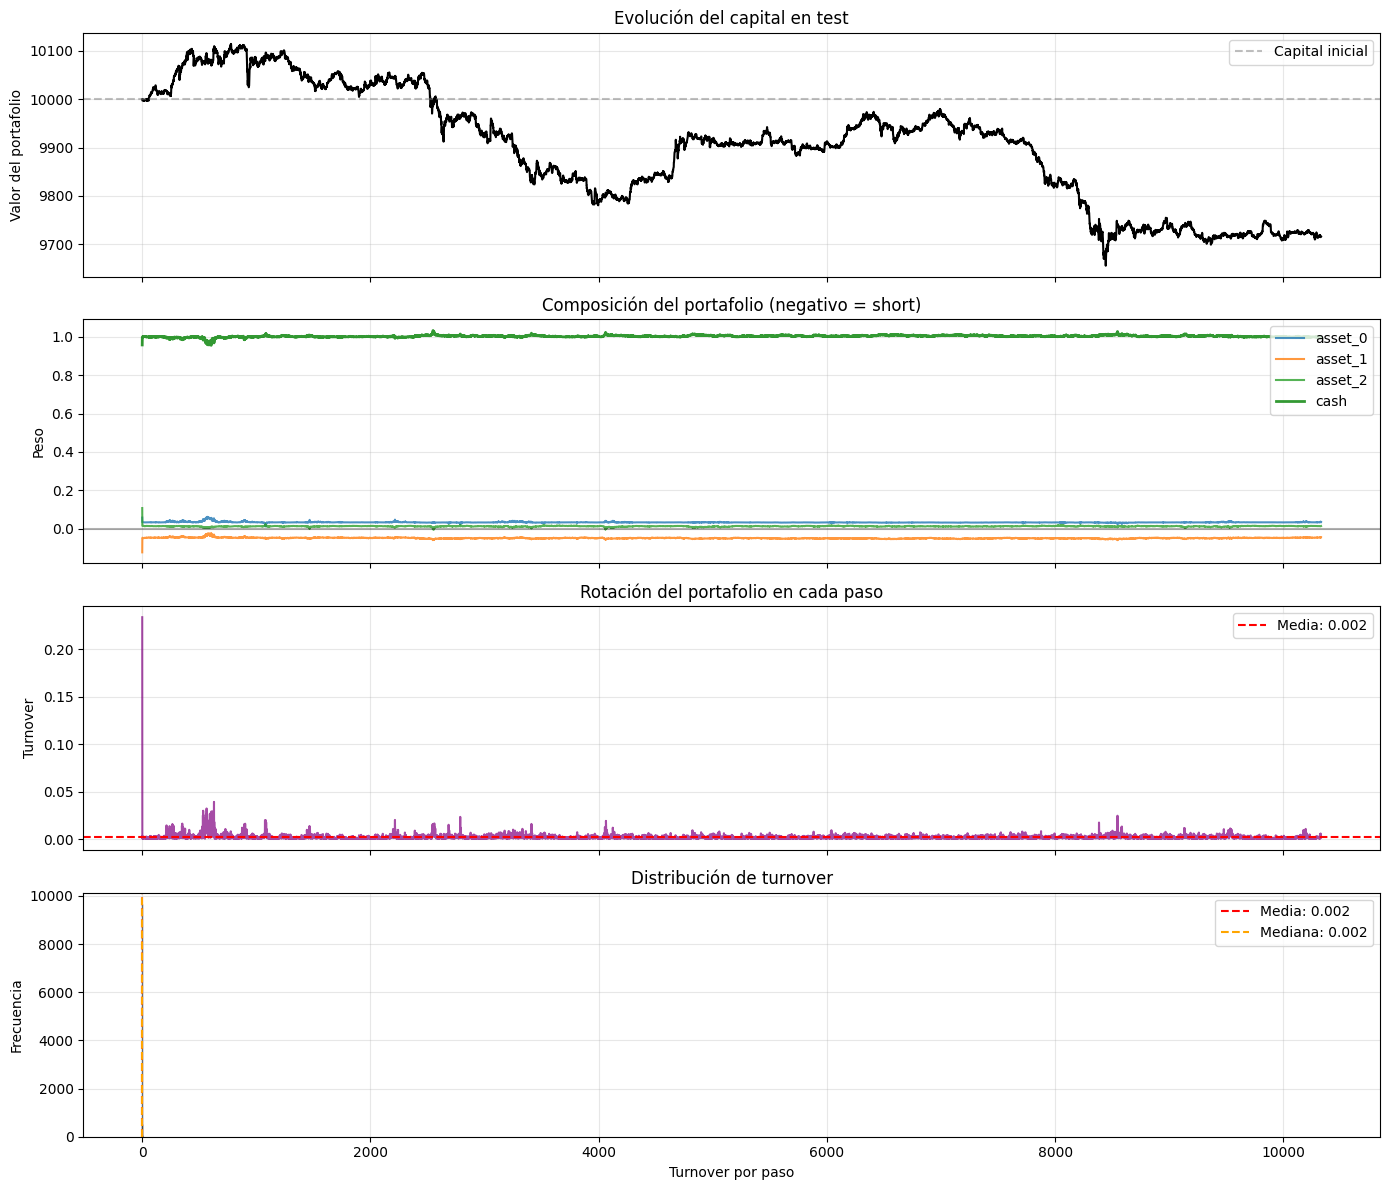


Gráfico guardado en 'inspection_test.png'


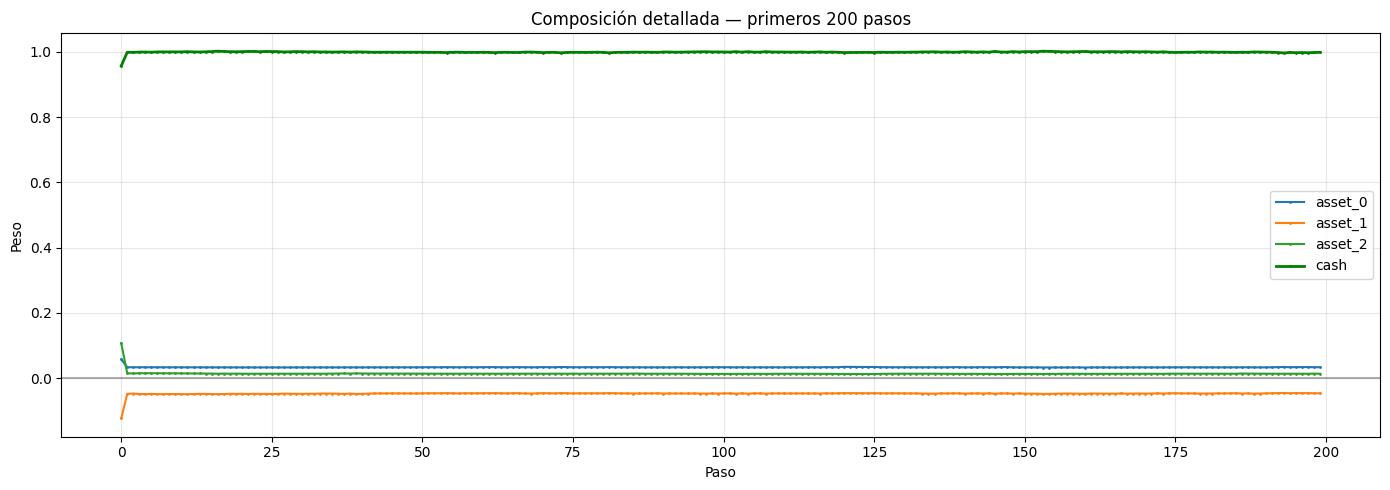

Zoom guardado en 'inspection_zoom.png'


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Reusa el TradingEnvEval (sin penalización) que ya definiste
test_env_inspect = TradingEnvEval(
    data_rl_test, encoder, scaler,
    episode_length=None,
    random_start=True,
    random_initial_portfolio=True,
)

# Asegúrate de que agent.ac tenga los pesos óptimos cargados
# (si reiniciaste el kernel, recarga con torch.load)

@torch.no_grad()
def inspect_episode(agent, env):
    agent.ac.eval()
    obs, _ = env.reset()
    obs = torch.from_numpy(obs).to(agent.device)
    
    weights_history = [env._weights.copy()]
    value_history = [env._value]
    turnover_history = []
    alpha_history = []
    rewards_history = []
    
    step = 0
    while True:
        alpha = agent.ac.get_alpha(obs.unsqueeze(0))
        action = (alpha / alpha.sum(dim=-1, keepdim=True)).squeeze(0)
        
        alpha_history.append(alpha.squeeze(0).cpu().numpy())
        
        next_obs, reward, terminated, truncated, info = env.step(action.cpu().numpy())
        
        weights_history.append(env._weights.copy())
        value_history.append(env._value)
        turnover_history.append(info.get("turnover", 0.0))
        rewards_history.append(reward)
        step += 1
        
        if terminated or truncated:
            break
        obs = torch.from_numpy(next_obs).to(agent.device)
    
    return {
        "weights": np.array(weights_history),       # (T+1, 4)
        "values": np.array(value_history),          # (T+1,)
        "turnover": np.array(turnover_history),     # (T,)
        "alpha": np.array(alpha_history),           # (T, 7)
        "rewards": np.array(rewards_history),       # (T,)
    }

result = inspect_episode(agent, test_env_inspect)

# ─────────── ESTADÍSTICAS ───────────
weights = result["weights"]
turnover = result["turnover"]
values = result["values"]

print("=" * 60)
print("ESTADÍSTICAS DEL COMPORTAMIENTO EN TEST")
print("=" * 60)
print(f"Pasos totales: {len(turnover)}")
print(f"Valor inicial: {values[0]:.2f}")
print(f"Valor final:   {values[-1]:.2f}")
print(f"Retorno total: {(values[-1]/values[0] - 1) * 100:+.2f}%")
print()
print("PORTAFOLIO (media por componente):")
print(f"  asset_0:  {weights[:, 0].mean():+.3f}  (desv: {weights[:, 0].std():.3f})")
print(f"  asset_1:  {weights[:, 1].mean():+.3f}  (desv: {weights[:, 1].std():.3f})")
print(f"  asset_2:  {weights[:, 2].mean():+.3f}  (desv: {weights[:, 2].std():.3f})")
print(f"  cash:     {weights[:, 3].mean():+.3f}  (desv: {weights[:, 3].std():.3f})")
print()
print("TURNOVER:")
print(f"  Medio:    {turnover.mean():.4f}")
print(f"  Mediana:  {np.median(turnover):.4f}")
print(f"  Max:      {turnover.max():.4f}")
print(f"  Min:      {turnover.min():.4f}")
print()
print("DISTRIBUCIÓN DE TURNOVER:")
print(f"  Pasos con turnover < 0.01 (casi sin mover): {(turnover < 0.01).sum()} ({(turnover < 0.01).mean()*100:.1f}%)")
print(f"  Pasos con turnover < 0.1  (movimientos pequeños): {(turnover < 0.1).sum()} ({(turnover < 0.1).mean()*100:.1f}%)")
print(f"  Pasos con turnover > 0.5  (movimientos grandes):  {(turnover > 0.5).sum()} ({(turnover > 0.5).mean()*100:.1f}%)")
print()
print("EXPOSICIÓN BRUTA |w_0|+|w_1|+|w_2|:")
gross = np.abs(weights[:, :3]).sum(axis=1)
print(f"  Media:    {gross.mean():.3f}")
print(f"  Mediana:  {np.median(gross):.3f}")
print(f"  Max:      {gross.max():.3f}")

# Drawdown
peak = np.maximum.accumulate(values)
drawdowns = (peak - values) / peak
print()
print(f"MAX DRAWDOWN: {drawdowns.max()*100:.2f}%")

# ─────────── GRÁFICOS ───────────
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# 1. Evolución del valor del portafolio
axes[0].plot(values, color='black')
axes[0].axhline(y=values[0], color='gray', linestyle='--', alpha=0.5, label='Capital inicial')
axes[0].set_ylabel("Valor del portafolio")
axes[0].set_title("Evolución del capital en test")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Pesos por activo a lo largo del tiempo
axes[1].plot(weights[:, 0], label='asset_0', alpha=0.8)
axes[1].plot(weights[:, 1], label='asset_1', alpha=0.8)
axes[1].plot(weights[:, 2], label='asset_2', alpha=0.8)
axes[1].plot(weights[:, 3], label='cash', alpha=0.8, color='green', linewidth=2)
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1].set_ylabel("Peso")
axes[1].set_title("Composición del portafolio (negativo = short)")
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

# 3. Turnover por paso
axes[2].plot(turnover, color='purple', alpha=0.7)
axes[2].axhline(y=turnover.mean(), color='red', linestyle='--', label=f'Media: {turnover.mean():.3f}')
axes[2].set_ylabel("Turnover")
axes[2].set_title("Rotación del portafolio en cada paso")
axes[2].legend()
axes[2].grid(alpha=0.3)

# 4. Histograma de turnover
axes[3].hist(turnover, bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[3].axvline(x=turnover.mean(), color='red', linestyle='--', label=f'Media: {turnover.mean():.3f}')
axes[3].axvline(x=np.median(turnover), color='orange', linestyle='--', label=f'Mediana: {np.median(turnover):.3f}')
axes[3].set_xlabel("Turnover por paso")
axes[3].set_ylabel("Frecuencia")
axes[3].set_title("Distribución de turnover")
axes[3].legend()
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("inspection_test.png", dpi=100, bbox_inches='tight')
plt.show()
print("\nGráfico guardado en 'inspection_test.png'")

# ─────────── ZOOM A LOS PRIMEROS 200 PASOS ───────────
fig2, ax = plt.subplots(figsize=(14, 5))
n_zoom = min(200, len(weights))
ax.plot(weights[:n_zoom, 0], label='asset_0', marker='.', markersize=2)
ax.plot(weights[:n_zoom, 1], label='asset_1', marker='.', markersize=2)
ax.plot(weights[:n_zoom, 2], label='asset_2', marker='.', markersize=2)
ax.plot(weights[:n_zoom, 3], label='cash', color='green', linewidth=2, marker='.', markersize=2)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel("Paso")
ax.set_ylabel("Peso")
ax.set_title(f"Composición detallada — primeros {n_zoom} pasos")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("inspection_zoom.png", dpi=100, bbox_inches='tight')
plt.show()
print("Zoom guardado en 'inspection_zoom.png'")


──── V1 (SIN penalización turnover) ────
Retorno total: -11.84%
Cash medio: 0.856  (desv: 0.026)
Exposición bruta media: 0.145
Turnover medio: 0.0186  mediana: 0.0164
Pesos medios: asset_0=+0.071  asset_1=+0.045  asset_2=+0.028
Desv pesos:   asset_0=0.0188   asset_1=0.0097   asset_2=0.0152

──── V2 (CON penalización turnover) ────
Retorno total: -2.83%
Cash medio: 1.002  (desv: 0.005)
Exposición bruta media: 0.095
Turnover medio: 0.0021  mediana: 0.0015
Pesos medios: asset_0=+0.034  asset_1=-0.049  asset_2=+0.013
Desv pesos:   asset_0=0.0024   asset_1=0.0027   asset_2=0.0019


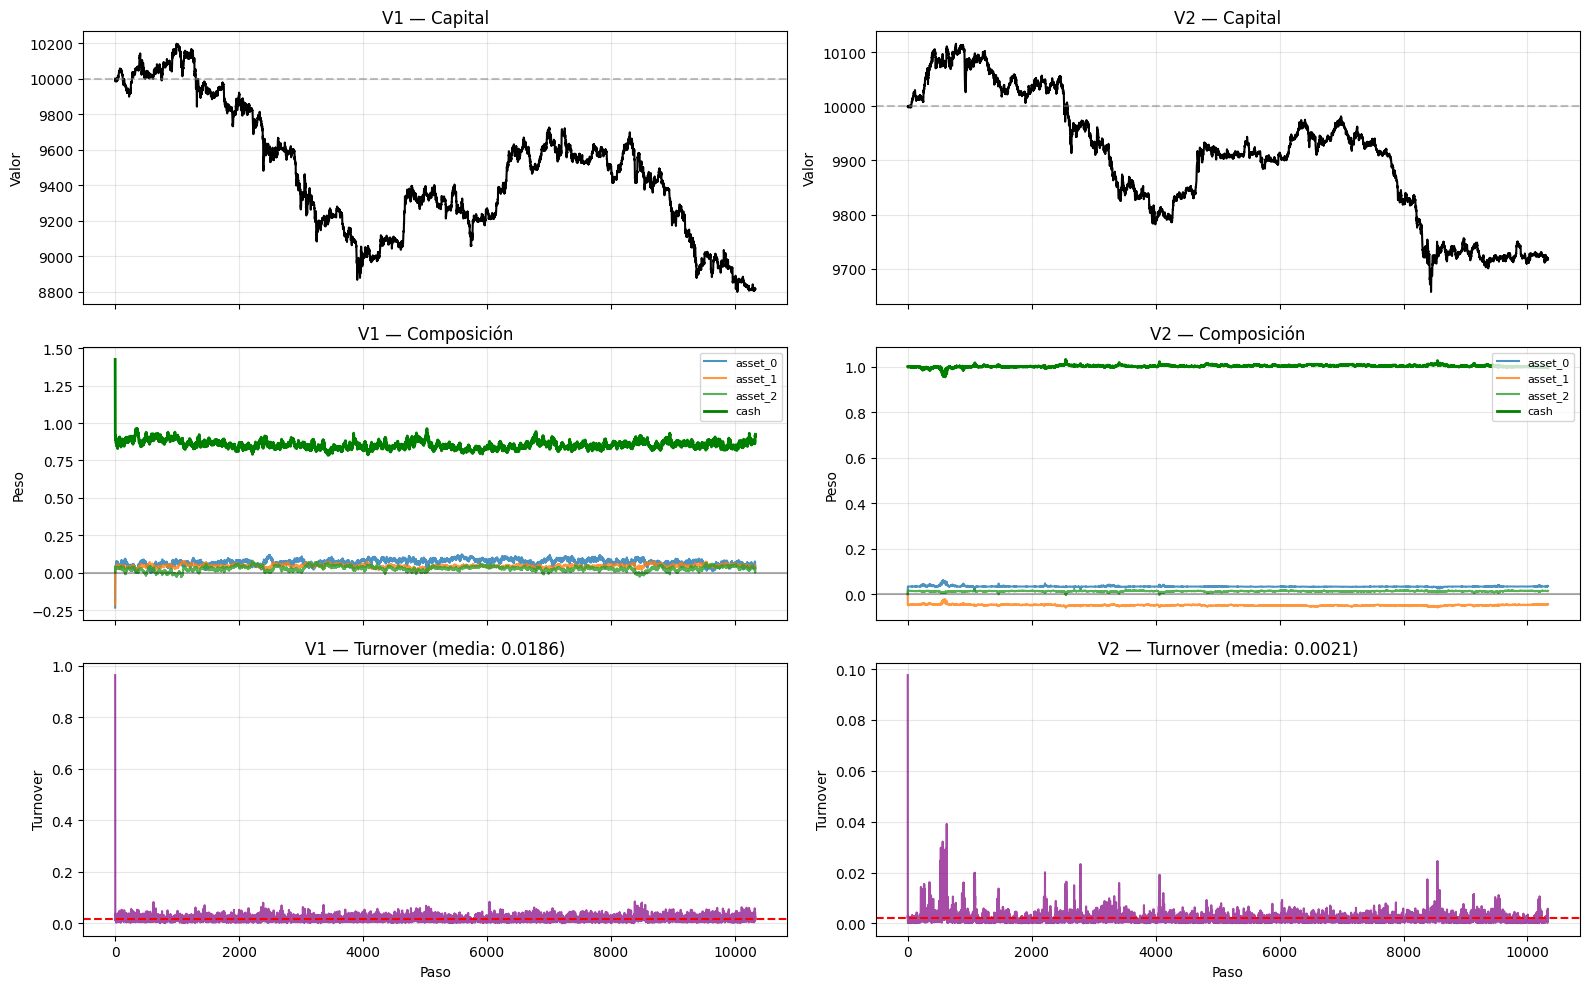


Gráfico comparativo guardado en 'v1_vs_v2_comparison.png'


In [31]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# Asegúrate de tener test_env_inspect ya construido como antes:
# test_env_inspect = TradingEnvEval(data_rl_test, encoder, scaler, ...)

@torch.no_grad()
def inspect_episode(agent, env):
    agent.ac.eval()
    obs, _ = env.reset()
    obs = torch.from_numpy(obs).to(agent.device)
    
    weights_history = [env._weights.copy()]
    value_history = [env._value]
    turnover_history = []
    alpha_history = []
    
    while True:
        alpha = agent.ac.get_alpha(obs.unsqueeze(0))
        action = (alpha / alpha.sum(dim=-1, keepdim=True)).squeeze(0)
        alpha_history.append(alpha.squeeze(0).cpu().numpy())
        
        next_obs, reward, terminated, truncated, info = env.step(action.cpu().numpy())
        
        weights_history.append(env._weights.copy())
        value_history.append(env._value)
        turnover_history.append(info.get("turnover", 0.0))
        
        if terminated or truncated:
            break
        obs = torch.from_numpy(next_obs).to(agent.device)
    
    return {
        "weights": np.array(weights_history),
        "values": np.array(value_history),
        "turnover": np.array(turnover_history),
        "alpha": np.array(alpha_history),
    }


# ─────────── CARGAR LOS DOS AGENTES ───────────
agent_v1 = Agent(obs_dim=68, n_actions=7)
agent_v1.ac.load_state_dict(torch.load("best_agent.pth", map_location=agent_v1.device))

agent_v2 = Agent(obs_dim=68, n_actions=7)
agent_v2.ac.load_state_dict(torch.load("best_agent_v2_turnover.pth", map_location=agent_v2.device))

# ─────────── EVALUAR LOS DOS SOBRE TEST ───────────
result_v1 = inspect_episode(agent_v1, test_env_inspect)

# Reconstruimos el env porque step() modifica estado interno
test_env_inspect_2 = TradingEnvEval(
    data_rl_test, encoder, scaler,
    episode_length=None,
    random_start=False,
    random_initial_portfolio=False,
)
result_v2 = inspect_episode(agent_v2, test_env_inspect_2)

# ─────────── COMPARAR ESTADÍSTICAS ───────────
def stats_summary(r, label):
    w = r["weights"]
    t = r["turnover"]
    v = r["values"]
    print(f"\n──── {label} ────")
    print(f"Retorno total: {(v[-1]/v[0] - 1) * 100:+.2f}%")
    print(f"Cash medio: {w[:, 3].mean():.3f}  (desv: {w[:, 3].std():.3f})")
    print(f"Exposición bruta media: {np.abs(w[:, :3]).sum(axis=1).mean():.3f}")
    print(f"Turnover medio: {t.mean():.4f}  mediana: {np.median(t):.4f}")
    print(f"Pesos medios: asset_0={w[:,0].mean():+.3f}  asset_1={w[:,1].mean():+.3f}  asset_2={w[:,2].mean():+.3f}")
    print(f"Desv pesos:   asset_0={w[:,0].std():.4f}   asset_1={w[:,1].std():.4f}   asset_2={w[:,2].std():.4f}")

stats_summary(result_v1, "V1 (SIN penalización turnover)")
stats_summary(result_v2, "V2 (CON penalización turnover)")

# ─────────── GRÁFICO COMPARATIVO ───────────
fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex='col')

for col, (result, label) in enumerate([(result_v1, "V1"), (result_v2, "V2")]):
    w = result["weights"]
    t = result["turnover"]
    v = result["values"]
    
    # Capital
    axes[0, col].plot(v, color='black')
    axes[0, col].axhline(y=v[0], color='gray', linestyle='--', alpha=0.5)
    axes[0, col].set_title(f"{label} — Capital")
    axes[0, col].set_ylabel("Valor")
    axes[0, col].grid(alpha=0.3)
    
    # Pesos
    axes[1, col].plot(w[:, 0], label='asset_0', alpha=0.8)
    axes[1, col].plot(w[:, 1], label='asset_1', alpha=0.8)
    axes[1, col].plot(w[:, 2], label='asset_2', alpha=0.8)
    axes[1, col].plot(w[:, 3], label='cash', color='green', linewidth=2)
    axes[1, col].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[1, col].set_title(f"{label} — Composición")
    axes[1, col].set_ylabel("Peso")
    axes[1, col].legend(loc='upper right', fontsize=8)
    axes[1, col].grid(alpha=0.3)
    
    # Turnover
    axes[2, col].plot(t, color='purple', alpha=0.7)
    axes[2, col].axhline(y=t.mean(), color='red', linestyle='--')
    axes[2, col].set_title(f"{label} — Turnover (media: {t.mean():.4f})")
    axes[2, col].set_ylabel("Turnover")
    axes[2, col].set_xlabel("Paso")
    axes[2, col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("v1_vs_v2_comparison.png", dpi=100, bbox_inches='tight')
plt.show()
print("\nGráfico comparativo guardado en 'v1_vs_v2_comparison.png'")